# Comparison: Data vs Simulation vs Smeared Simulation

This notebook compares the experimental data with GEANT4 simulation (original and smeared).

**Important: Simulation Input Requirements:**
- **Simulation files are pre-filtered by `simc_pi0_analysis.C`**
- Only events passing HMS electron cuts (including hreactz: -4.0 < z < 4.0 cm) are stored
- This ensures consistency with data analysis and nps_sim_smearing_new.C
- This notebook applies only `nclust == 2` cut (HMS cuts already applied upstream)

**Smearing consistency contract:**
- **No smearing is performed in this notebook**
- Smeared observables are read directly from `simc_pi0_analysis_output_smeared.root`
- `simc_pi0_analysis.C` applies the same method as `nps_sim_smearing_new.C`:
  - Energy: `E_smeared = Gaus(mu * E, sigma_E(E_scaled))`
  - Position: `x/y_smeared = x/y + Gaus(0, sigma_pos)`
  - Missing mass uses electron momentum scaled by `best_p_e_scale`

**Weighting/selection mode:**
- Controlled by `APPLY_IS_EXCLUSIVE_SELECTION` in the weighting cell
- `False` (default): use all events (`is_exclusive` factor = 1)
- `True`: multiply both data and simulation weights by `is_exclusive` when branch is available
- Data base weight: `pi0_weight * scale`
- Simulation base weight: `full_weight`

In [1]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.gridspec import GridSpec

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## Load Data Files

In [2]:
# File paths
data_file = "../output/plots/x60_4b/production_wfpi0/combined_branches_LH2_wfpi0.root"  # Experimental data
sim_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output.root"  # Unsmeared simulation
sim_smeared_file = "../output/plots/x60_4b/production_wfpi0/simc_pi0_analysis_output_smeared.root"  # Smeared simulation

# Open files explicitly so we can verify smearing metadata tags
print("Loading data...")
data_root = uproot.open(data_file)
data_tree = data_root["physics"]
print(f"Data entries: {data_tree.num_entries}")

print("\nLoading simulation...")
sim_root = uproot.open(sim_file)
sim_tree = sim_root["simulation"]
print(f"Simulation entries: {sim_tree.num_entries}")

print("\nLoading smeared simulation...")
sim_smeared_root = uproot.open(sim_smeared_file)
sim_smeared_tree = sim_smeared_root["simulation"]
print(f"Smeared simulation entries: {sim_smeared_tree.num_entries}")

# Verify smearing metadata contract against section-based nps_sim_smearing_new.C output
smearing_method = "missing"
smearing_source = "missing"
smearing_mode = "missing"
try:
    method_obj = sim_smeared_root["smearing_method"]
    source_obj = sim_smeared_root["smearing_source"]
    mode_obj = sim_smeared_root["smearing_mode"]
    smearing_method = method_obj.member("fTitle")
    smearing_source = source_obj.member("fTitle")
    smearing_mode = mode_obj.member("fTitle")
    print("\nSmearing metadata (from simc_pi0_analysis_output_smeared.root):")
    print(f"  mode:   {smearing_mode}")
    print(f"  source: {smearing_source}")
    print(f"  method: {smearing_method}")
except Exception as exc:
    print("\nWarning: smearing metadata tags not found in smeared file.")
    print("         Re-run simc_pi0_analysis.C after latest consistency updates.")
    print(f"         Details: {exc}")

# Fail early if notebook input is not section-mode calibrated output.
if smearing_mode not in ("missing", "section"):
    raise RuntimeError(
        f"Notebook expects section-mode smearing to match chi2_scans.pdf, got smearing_mode='{smearing_mode}'. "
        "Re-run simc_pi0_analysis.C after the event-mode removal update."
    )

Loading data...
Data entries: 879841

Loading simulation...
Simulation entries: 210677

Loading smeared simulation...
Smeared simulation entries: 210677

Smearing metadata (from simc_pi0_analysis_output_smeared.root):
  mode:   section
  source: section_map.csv fields: best_mu,best_sigma,best_sigma_pos_cm,best_p_e_scale,res_A,res_B,res_C
  method: nps_sim_smearing_new.C-consistent: E' uses Gaussian/Landau with sigma_E(E_scaled), optional mu(E)=mu0*((E0/(E+Eshift))^b+1), optional sigma_pos(E)=sigma_pos_ref*sqrt(E0/E), optional pair-energy correction vs m_gg, and optional mmiss electron momentum scaling via p_e_scale.


## Extract Variables

In [3]:
# Branch name mapping: data -> simulation
# Data uses different branch names
data_branch_map = {
    'mpi0': 'mpi0_all',
    'mmiss': 'mmiss_all',  # Use corrected missing mass
    'Q2': 'Q2',
    'W': 'W',
    'xB': 'xB',
    'z': 'z',
    'theta': 'theta',
    'weight': 'pi0_weight',
    'scale': 'scale',
    'nclust': 'nclust_selected',
    'is_exclusive': 'is_exclusive',
    # Cluster position and energy for both photons (data only)
    'cluster_x_1': 'cluster_x_1',
    'cluster_y_1': 'cluster_y_1',
    'cluster_e_1': 'cluster_e_1',
    'cluster_x_2': 'cluster_x_2',
    'cluster_y_2': 'cluster_y_2',
    'cluster_e_2': 'cluster_e_2'
}

# Variables to compare (using simulation names as standard)
variables = ['mpi0', 'mmiss', 'Q2', 'W', 'xB', 'z', 'theta', 
             'weight', 'scale', 'nclust', 'is_exclusive']

# Data-only cluster variables
data_cluster_vars = ['cluster_x_1', 'cluster_y_1', 'cluster_e_1',
                     'cluster_x_2', 'cluster_y_2', 'cluster_e_2']

# Load data (with branch name mapping)
print("Extracting data variables...")
data = {}
for var in variables + data_cluster_vars:
    data_branch = data_branch_map.get(var, var)
    if data_branch in data_tree.keys():
        data[var] = data_tree[data_branch].array(library="np")
    else:
        print(f"Warning: {data_branch} not found in data")
        data[var] = np.array([])

# Load simulation (note: sim uses different HMS branch names)
print("Extracting simulation variables...")
sim = {}
sim_branch_map = {
    'theta': 'theta_e',
    'weight': 'full_weight'
}
sim_variables = variables
for var in sim_variables:
    sim_branch = sim_branch_map.get(var, var)
    if sim_branch in sim_tree.keys():
        sim[var] = sim_tree[sim_branch].array(library="np")
    else:
        if var == 'is_exclusive':
            sim[var] = np.ones(sim_tree.num_entries, dtype=float)
            print("Info: simulation is_exclusive not found, defaulting to 1.")
        else:
            print(f"Warning: {sim_branch} not found in simulation")
            sim[var] = np.array([])

# Load simulation cluster arrays (these contain all clusters, not individual ones)
print("Extracting simulation cluster variables...")
if 'clust_X' in sim_tree.keys():
    sim['clust_X'] = sim_tree['clust_X'].array(library="np")
if 'clust_Y' in sim_tree.keys():
    sim['clust_Y'] = sim_tree['clust_Y'].array(library="np")
if 'clust_E' in sim_tree.keys():
    sim['clust_E'] = sim_tree['clust_E'].array(library="np")

# Load smeared simulation (same branch names as unsmeared sim)
print("Extracting smeared simulation variables...")
sim_smeared = {}
for var in sim_variables:
    sim_branch = sim_branch_map.get(var, var)
    if sim_branch in sim_smeared_tree.keys():
        sim_smeared[var] = sim_smeared_tree[sim_branch].array(library="np")
    else:
        if var == 'is_exclusive':
            sim_smeared[var] = np.ones(sim_smeared_tree.num_entries, dtype=float)
            print("Info: smeared simulation is_exclusive not found, defaulting to 1.")
        else:
            print(f"Warning: {sim_branch} not found in smeared simulation")
            sim_smeared[var] = np.array([])

# Load smeared simulation cluster arrays
print("Extracting smeared simulation cluster variables...")
if 'clust_X' in sim_smeared_tree.keys():
    sim_smeared['clust_X'] = sim_smeared_tree['clust_X'].array(library="np")
if 'clust_Y' in sim_smeared_tree.keys():
    sim_smeared['clust_Y'] = sim_smeared_tree['clust_Y'].array(library="np")
if 'clust_E' in sim_smeared_tree.keys():
    sim_smeared['clust_E'] = sim_smeared_tree['clust_E'].array(library="np")

print("\nData extraction complete!")

Extracting data variables...
Extracting simulation variables...
Extracting simulation cluster variables...
Extracting smeared simulation variables...
Extracting smeared simulation cluster variables...

Data extraction complete!


## Apply Cuts and Calculate Weights

**Note:** Simulation files are pre-filtered by `simc_pi0_analysis.C` with HMS electron cuts already applied.
This notebook only applies `nclust == 2` and then applies optional exclusivity weighting via `APPLY_IS_EXCLUSIVE_SELECTION`.

In [4]:
# NOTE: Simulation files are pre-filtered by simc_pi0_analysis.C
#       HMS electron cuts are already applied in production.
#       To match chi2_scans.pdf, we also require both photons inside fitter geometry.

APPLY_IS_EXCLUSIVE_SELECTION = False

# Match fitter geometry/domain used for calibration summary histograms
X_MIN, X_MAX = -24.0, 28.0
Y_MIN, Y_MAX = -34.0, 34.0

# Match fitter histogram windows
FITTER_WINDOWS = {
    'mpi0': (0.128, 0.142),
    'mmiss': (0.8, 1.0),
    'mpgg2': (7.8, 12.2),
}

def in_geom_xy(x, y):
    return (x >= X_MIN) & (x <= X_MAX) & (y >= Y_MIN) & (y <= Y_MAX)

def first_two_in_geometry(xarr, yarr):
    out = np.zeros(len(xarr), dtype=bool)
    for i, (xevt, yevt) in enumerate(zip(xarr, yarr)):
        try:
            if len(xevt) < 2 or len(yevt) < 2:
                continue
            x1, x2 = float(xevt[0]), float(xevt[1])
            y1, y2 = float(yevt[0]), float(yevt[1])
            out[i] = (X_MIN <= x1 <= X_MAX and X_MIN <= x2 <= X_MAX and
                      Y_MIN <= y1 <= Y_MAX and Y_MIN <= y2 <= Y_MAX)
        except Exception:
            out[i] = False
    return out

# nclust==2 masks
data_ncl2 = data['nclust'] == 2 if len(data['nclust']) > 0 else np.ones(len(data['mpi0']), dtype=bool)
sim_ncl2 = sim['nclust'] == 2 if len(sim['nclust']) > 0 else np.ones(len(sim['mpi0']), dtype=bool)
sim_smeared_ncl2 = sim_smeared['nclust'] == 2 if len(sim_smeared['nclust']) > 0 else np.ones(len(sim_smeared['mpi0']), dtype=bool)

# both-photon-in-geometry masks
data_geo = in_geom_xy(data['cluster_x_1'], data['cluster_y_1']) & in_geom_xy(data['cluster_x_2'], data['cluster_y_2'])
sim_geo = first_two_in_geometry(sim['clust_X'], sim['clust_Y']) if ('clust_X' in sim and 'clust_Y' in sim) else np.ones(len(sim['mpi0']), dtype=bool)
sim_smeared_geo = first_two_in_geometry(sim_smeared['clust_X'], sim_smeared['clust_Y']) if ('clust_X' in sim_smeared and 'clust_Y' in sim_smeared) else np.ones(len(sim_smeared['mpi0']), dtype=bool)

# Final analysis masks (consistent event domain)
data_cut = data_ncl2 & data_geo
sim_cut = sim_ncl2 & sim_geo
sim_smeared_cut = sim_smeared_ncl2 & sim_smeared_geo

print(f"Data events after nclust==2: {np.sum(data_ncl2)}")
print(f"Sim events after nclust==2: {np.sum(sim_ncl2)}")
print(f"Smeared sim events after nclust==2: {np.sum(sim_smeared_ncl2)}")
print(f"Data events after geometry gate: {np.sum(data_cut)}")
print(f"Sim events after geometry gate: {np.sum(sim_cut)}")
print(f"Smeared sim events after geometry gate: {np.sum(sim_smeared_cut)}")

def get_exclusive_factor(sample, cut_mask, sample_name):
    nsel = int(np.sum(cut_mask))
    if not APPLY_IS_EXCLUSIVE_SELECTION:
        return np.ones(nsel, dtype=float)
    if 'is_exclusive' in sample and len(sample['is_exclusive']) > 0:
        return sample['is_exclusive'][cut_mask].astype(float)
    print(f"Warning: {sample_name} missing is_exclusive; using factor=1.")
    return np.ones(nsel, dtype=float)

# Data weights: base = pi0_weight * scale, optional is_exclusive factor
base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
scale_factor = data['scale'][data_cut] if len(data['scale']) > 0 else np.ones(np.sum(data_cut))
data_excl_factor = get_exclusive_factor(data, data_cut, 'data')
data_weights = base_weight * scale_factor * data_excl_factor
data_total = np.sum(data_weights)

# Simulation weights: base = full_weight, optional is_exclusive factor
sim_base_weights = sim['weight'][sim_cut] if len(sim['weight']) > 0 else np.ones(np.sum(sim_cut))
sim_excl_factor = get_exclusive_factor(sim, sim_cut, 'simulation')
sim_weights = sim_base_weights * sim_excl_factor
sim_total_weighted = np.sum(sim_weights)

sim_smeared_base_weights = sim_smeared['weight'][sim_smeared_cut] if len(sim_smeared['weight']) > 0 else np.ones(np.sum(sim_smeared_cut))
sim_smeared_excl_factor = get_exclusive_factor(sim_smeared, sim_smeared_cut, 'smeared simulation')
sim_smeared_weights = sim_smeared_base_weights * sim_smeared_excl_factor
sim_smeared_total_weighted = np.sum(sim_smeared_weights)

mode_label = 'exclusive-weighted' if APPLY_IS_EXCLUSIVE_SELECTION else 'all-events'
print(f"\nWeighting mode: {mode_label}")
print(f"Data total (weighted): {data_total:.2f}")
print(f"Simulation total (weighted): {sim_total_weighted:.2f}")
print(f"Smeared simulation total (weighted): {sim_smeared_total_weighted:.2f}")

print("\nData weighting: pi0_weight * scale * optional(is_exclusive)")
print("Simulation weighting: full_weight * optional(is_exclusive)")

Data events after nclust==2: 819006
Sim events after nclust==2: 210677
Smeared sim events after nclust==2: 210677
Data events after geometry gate: 635828
Sim events after geometry gate: 157189
Smeared sim events after geometry gate: 157189

Weighting mode: all-events
Data total (weighted): 211450.10
Simulation total (weighted): 80.88
Smeared simulation total (weighted): 80.88

Data weighting: pi0_weight * scale * optional(is_exclusive)
Simulation weighting: full_weight * optional(is_exclusive)


## Comparison Function

In [5]:
def plot_comparison(var_name, bins=100, range_vals=None, xlabel=None, title=None, log_scale=False):
    """
    Plot comparison of data, simulation, and smeared simulation.
    Weighting follows global mode configured in the weighting cell:
      - data: pi0_weight * scale * optional(is_exclusive)
      - sim : full_weight * optional(is_exclusive)
    """
    from matplotlib.ticker import AutoMinorLocator
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), 
                                    gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    # Get data for this variable
    data_vals = data[var_name][data_cut]
    sim_vals = sim[var_name][sim_cut]
    sim_smeared_vals = sim_smeared[var_name][sim_smeared_cut]
    
    # Reuse global per-event weights from weighting cell
    data_weights_var = data_weights
    sim_weights_var = sim_weights
    sim_smeared_weights_var = sim_smeared_weights
    
    # Determine range if not provided
    if range_vals is None:
        # Use data range, filter out sentinel values
        valid_data = data_vals[data_vals > -900]
        if len(valid_data) > 0:
            p1, p99 = np.percentile(valid_data, [1, 99])
            range_vals = (p1, p99)
        else:
            range_vals = (np.min(data_vals), np.max(data_vals))
    
    # Main plot
    # Data histogram
    data_counts, bin_edges, _ = ax1.hist(data_vals, bins=bins, range=range_vals, 
                                          weights=data_weights_var,
                                          histtype='step', color='black', linewidth=2, 
                                          label='Data', density=False)
    
    # Simulation histogram (unsmeared)
    sim_counts, _, _ = ax1.hist(sim_vals, bins=bin_edges, weights=sim_weights_var,
                                 histtype='step', color='blue', linewidth=2, 
                                 label='Simulation (unsmeared)', density=False, linestyle='--')
    
    # Smeared simulation histogram
    sim_smeared_counts, _, _ = ax1.hist(sim_smeared_vals, bins=bin_edges, weights=sim_smeared_weights_var,
                                         histtype='step', color='red', linewidth=2, 
                                         label='Simulation (smeared)', density=False)
    
    # Normalize each histogram to its own integral
    data_integral = np.sum(data_counts)
    sim_integral = np.sum(sim_counts)
    sim_smeared_integral = np.sum(sim_smeared_counts)
    
    if data_integral > 0:
        data_counts = data_counts / data_integral
    if sim_integral > 0:
        sim_counts = sim_counts / sim_integral
    if sim_smeared_integral > 0:
        sim_smeared_counts = sim_smeared_counts / sim_smeared_integral
    
    # Clear and redraw with normalized histograms
    ax1.clear()
    ax1.stairs(data_counts, bin_edges, color='black', linewidth=2, label='Data')
    ax1.stairs(sim_counts, bin_edges, color='blue', linewidth=2, label='Simulation (unsmeared)', linestyle='--')
    ax1.stairs(sim_smeared_counts, bin_edges, color='red', linewidth=2, label='Simulation (smeared)')
    
    ax1.set_ylabel('Normalized Counts', fontsize=14)
    ax1.legend(fontsize=12, loc='best')
    if title:
        ax1.set_title(title, fontsize=16)
    if log_scale:
        ax1.set_yscale('log')
    ax1.minorticks_on()
    ax1.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax1.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax1.set_axisbelow(False)
    ax1.grid(True, which='major', linestyle='--', linewidth=1.0, color='gray', alpha=0.75, zorder=10)
    ax1.grid(True, which='minor', linestyle=':', linewidth=0.8, color='gray', alpha=0.55, zorder=10)
    ax1.tick_params(labelbottom=False)
    
    # Ratio plot
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # Calculate ratios (avoid division by zero)
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_sim = np.where(data_counts > 0, sim_counts / data_counts, np.nan)
        ratio_smeared = np.where(data_counts > 0, sim_smeared_counts / data_counts, np.nan)
    
    # Plot ratios
    ax2.plot(bin_centers, ratio_sim, 'o-', color='blue', label='Unsmeared / Data', markersize=4)
    ax2.plot(bin_centers, ratio_smeared, 's-', color='red', label='Smeared / Data', markersize=4)
    ax2.axhline(y=1, color='black', linestyle='--', linewidth=1)
    ax2.set_xlabel(xlabel if xlabel else var_name, fontsize=14)
    ax2.set_ylabel('Sim / Data', fontsize=14)
    ax2.set_ylim(0.5, 1.5)
    ax2.legend(fontsize=10, loc='best')
    ax2.minorticks_on()
    ax2.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax2.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax2.set_axisbelow(False)
    ax2.grid(True, which='major', linestyle='--', linewidth=1.0, color='gray', alpha=0.75, zorder=10)
    ax2.grid(True, which='minor', linestyle=':', linewidth=0.8, color='gray', alpha=0.55, zorder=10)
    ax2.set_xlim(range_vals)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print(f"\n{var_name} Statistics:")
    print(f"Data:             mean={np.mean(data_vals):.4f}, std={np.std(data_vals):.4f}")
    print(f"Sim (unsmeared):  mean={np.mean(sim_vals):.4f}, std={np.std(sim_vals):.4f}")
    print(f"Sim (smeared):    mean={np.mean(sim_smeared_vals):.4f}, std={np.std(sim_smeared_vals):.4f}")

## Pi0 Invariant Mass Comparison

## Missing Mass Comparison

/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


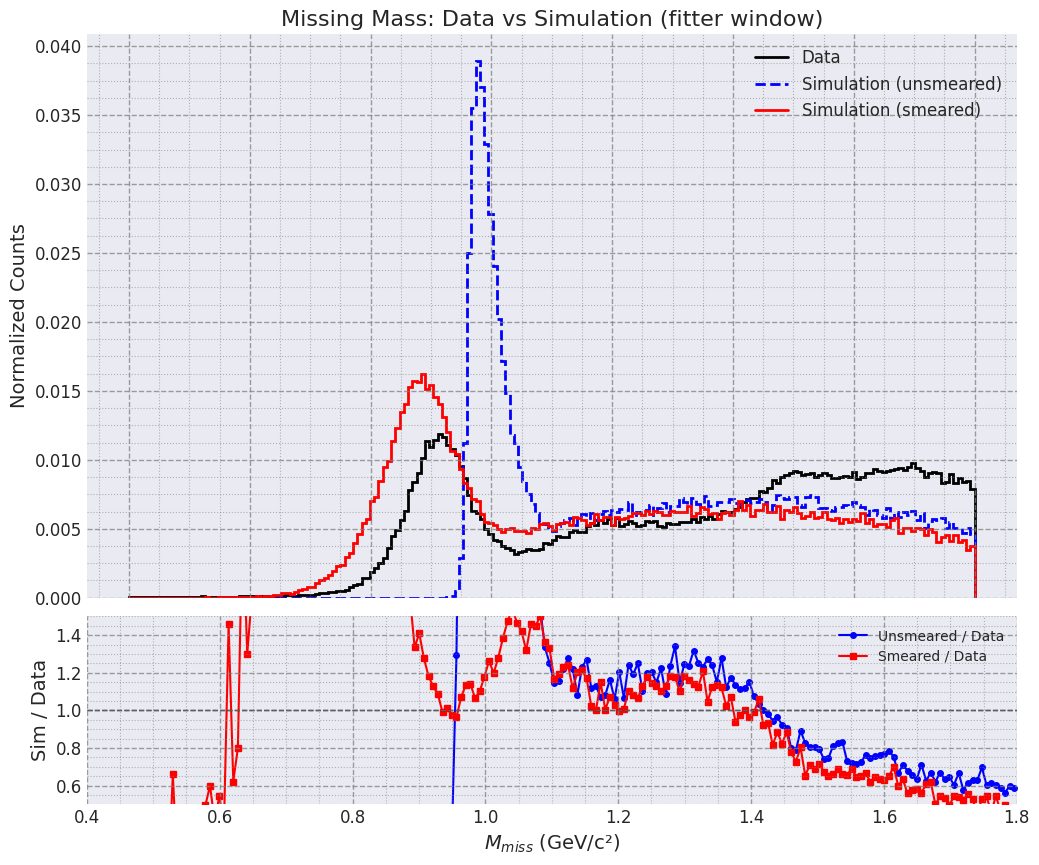


mmiss Statistics:
Data:             mean=1.6035, std=0.3940
Sim (unsmeared):  mean=1.2342, std=0.2745
Sim (smeared):    mean=1.1365, std=0.3080


In [6]:
plot_comparison('mmiss', bins=200, range_vals=(0.4,1.8), 
                xlabel=r'$M_{miss}$ (GeV/c²)', 
                title='Missing Mass: Data vs Simulation (fitter window)')

w_mpgg2_energy = 1.000000
mpgg2 entries: data=879841, sim=210677, smeared=210677


/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


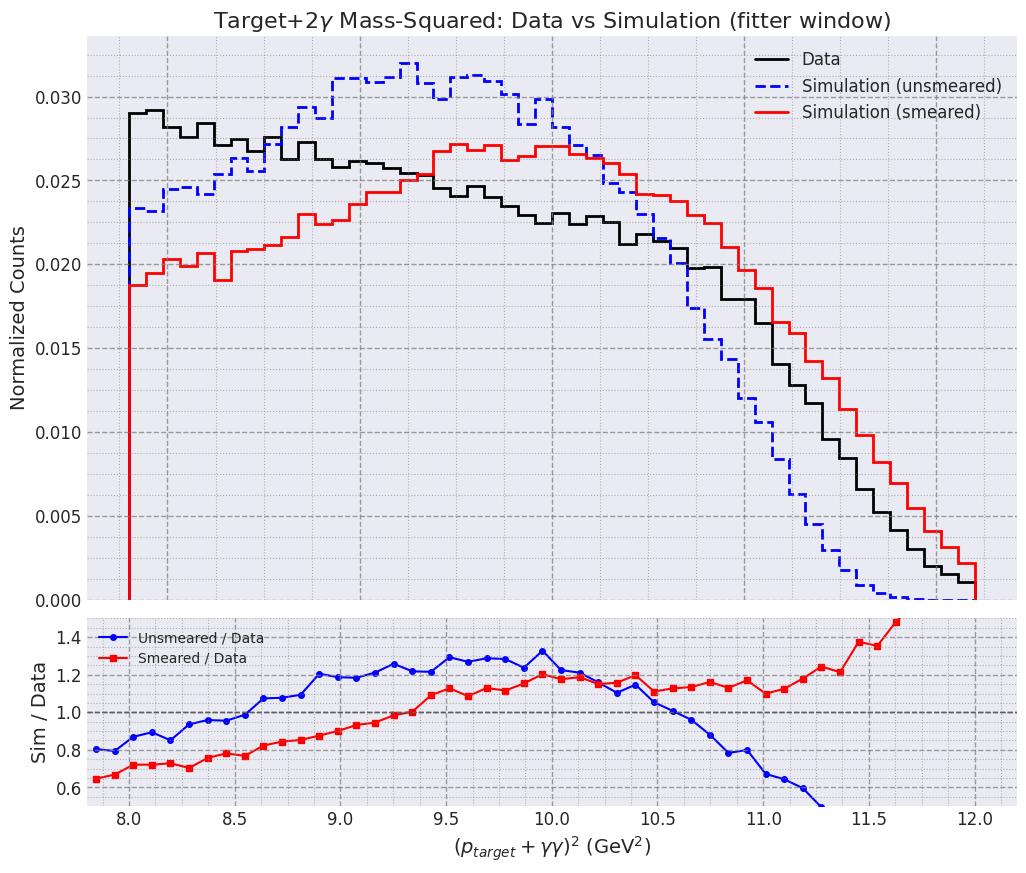


mpgg2 Statistics:
Data:             mean=6.8251, std=2.0627
Sim (unsmeared):  mean=8.7634, std=1.5927
Sim (smeared):    mean=9.2190, std=1.6937


In [7]:
# Build mpgg2 = (p_target + gamma1 + gamma2)^2
proton_mass = 0.9382720813  # GeV

# Match C++ configurable scaling: E -> w_mpgg2_energy
w_mpgg2_energy = 1.0

def first_two_energy_sum(clust_e_array):
    return np.array([evt[0] + evt[1] if len(evt) >= 2 else np.nan for evt in clust_e_array], dtype=float)

if 'mpi0' in data and 'cluster_e_1' in data and 'cluster_e_2' in data:
    data['mpgg2'] = (
        proton_mass**2
        + (w_mpgg2_energy**2) * data['mpi0']**2
        + 2.0 * proton_mass * w_mpgg2_energy * (data['cluster_e_1'] + data['cluster_e_2'])
    )
else:
    data['mpgg2'] = np.array([])

if 'mpi0' in sim and 'clust_E' in sim:
    sim_e_sum = first_two_energy_sum(sim['clust_E'])
    sim['mpgg2'] = (
        proton_mass**2
        + (w_mpgg2_energy**2) * sim['mpi0']**2
        + 2.0 * proton_mass * w_mpgg2_energy * sim_e_sum
    )
else:
    sim['mpgg2'] = np.array([])

if 'mpi0' in sim_smeared and 'clust_E' in sim_smeared:
    sim_smeared_e_sum = first_two_energy_sum(sim_smeared['clust_E'])
    sim_smeared['mpgg2'] = (
        proton_mass**2
        + (w_mpgg2_energy**2) * sim_smeared['mpi0']**2
        + 2.0 * proton_mass * w_mpgg2_energy * sim_smeared_e_sum
    )
else:
    sim_smeared['mpgg2'] = np.array([])

print(f"w_mpgg2_energy = {w_mpgg2_energy:.6f}")
print(f"mpgg2 entries: data={len(data['mpgg2'])}, sim={len(sim['mpgg2'])}, smeared={len(sim_smeared['mpgg2'])}")

plot_comparison('mpgg2', bins=50, range_vals=FITTER_WINDOWS['mpgg2'],
                xlabel=r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)',
                title=r'Target+2$\gamma$ Mass-Squared: Data vs Simulation (fitter window)')

## Target+2γ Mass-Squared Comparison

In [8]:
# Peak Position Analysis for Missing Mass in fitter window

def find_peak_position(values, weights=None, bins=120, range_vals=FITTER_WINDOWS['mmiss']):
    counts, bin_edges = np.histogram(values, bins=bins, range=range_vals, weights=weights)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width = bin_edges[1] - bin_edges[0]

    max_idx = np.argmax(counts)
    peak_start = max(0, max_idx - 2)
    peak_end = min(len(counts), max_idx + 3)

    peak_region_counts = counts[peak_start:peak_end]
    peak_region_centers = bin_centers[peak_start:peak_end]

    if np.sum(peak_region_counts) > 0:
        peak_pos = np.sum(peak_region_centers * peak_region_counts) / np.sum(peak_region_counts)
        variance = np.sum(peak_region_counts * (peak_region_centers - peak_pos)**2) / np.sum(peak_region_counts)
        peak_err = np.sqrt(variance / np.sum(peak_region_counts))
    else:
        peak_pos = bin_centers[max_idx]
        peak_err = bin_width / 2

    return peak_pos, peak_err, counts, bin_edges

print("=" * 80)
print("MISSING MASS PEAK POSITION ANALYSIS (fitter window)")
print("=" * 80)

bins = 120
range_vals = FITTER_WINDOWS['mmiss']

data_vals = data['mmiss'][data_cut]
print("\nData:")
data_peak, data_err, data_counts, bin_edges = find_peak_position(
    data_vals, weights=data_weights, bins=bins, range_vals=range_vals
)
print(f"  Peak position: {data_peak:.6f} +/- {data_err:.6f} GeV/c^2")

sim_vals = sim['mmiss'][sim_cut]
print("\nUnsmeared Simulation:")
sim_peak, sim_err, sim_counts, _ = find_peak_position(
    sim_vals, weights=sim_weights, bins=bins, range_vals=range_vals
)
print(f"  Peak position: {sim_peak:.6f} +/- {sim_err:.6f} GeV/c^2")

sim_smeared_vals = sim_smeared['mmiss'][sim_smeared_cut]
print("\nSmeared Simulation:")
sim_smeared_peak, sim_smeared_err, sim_smeared_counts, _ = find_peak_position(
    sim_smeared_vals, weights=sim_smeared_weights, bins=bins, range_vals=range_vals
)
print(f"  Peak position: {sim_smeared_peak:.6f} +/- {sim_smeared_err:.6f} GeV/c^2")

print("\n" + "=" * 80)
print("PEAK POSITION DIFFERENCES")
print("=" * 80)

diff_data_sim = sim_peak - data_peak
diff_data_sim_err = np.sqrt(data_err**2 + sim_err**2)

diff_data_smeared = sim_smeared_peak - data_peak
diff_data_smeared_err = np.sqrt(data_err**2 + sim_smeared_err**2)

diff_smeared_sim = sim_smeared_peak - sim_peak
diff_smeared_sim_err = np.sqrt(sim_err**2 + sim_smeared_err**2)

print(f"\nUnsmeared Sim - Data:   {diff_data_sim:+.6f} +/- {diff_data_sim_err:.6f} GeV/c^2")
print(f"                        ({diff_data_sim*1000:+.3f} +/- {diff_data_sim_err*1000:.3f} MeV/c^2)")

print(f"\nSmeared Sim - Data:     {diff_data_smeared:+.6f} +/- {diff_data_smeared_err:.6f} GeV/c^2")
print(f"                        ({diff_data_smeared*1000:+.3f} +/- {diff_data_smeared_err*1000:.3f} MeV/c^2)")

print(f"\nSmeared - Unsmeared:    {diff_smeared_sim:+.6f} +/- {diff_smeared_sim_err:.6f} GeV/c^2")
print(f"                        ({diff_smeared_sim*1000:+.3f} +/- {diff_smeared_sim_err*1000:.3f} MeV/c^2)")

MISSING MASS PEAK POSITION ANALYSIS (fitter window)

Data:
  Peak position: 0.912552 +/- 0.000049 GeV/c^2

Unsmeared Simulation:
  Peak position: 0.979130 +/- 0.001284 GeV/c^2

Smeared Simulation:
  Peak position: 0.885821 +/- 0.001944 GeV/c^2

PEAK POSITION DIFFERENCES

Unsmeared Sim - Data:   +0.066577 +/- 0.001285 GeV/c^2
                        (+66.577 +/- 1.285 MeV/c^2)

Smeared Sim - Data:     -0.026731 +/- 0.001945 GeV/c^2
                        (-26.731 +/- 1.945 MeV/c^2)

Smeared - Unsmeared:    -0.093309 +/- 0.002330 GeV/c^2
                        (-93.309 +/- 2.330 MeV/c^2)


## Energy Scale Error Analysis

Calculate the implied photon energy scale error from the missing mass peak mismatch.

In [9]:
# Calculate implied energy scale error from missing mass mismatch
# Physics: ΔM_x ≈ -Δα·E_π0, where Δα is fractional energy scale error

print("=" * 80)
print("ENERGY SCALE ERROR ANALYSIS")
print("=" * 80)

# Calculate average pi0 energy from data
# E_pi0 can be estimated from cluster energies (photon pair energy sum)
data_e1 = data['cluster_e_1'][data_cut]
data_e2 = data['cluster_e_2'][data_cut]
data_pi0_energy = data_e1 + data_e2

# Use the same global weighting convention selected in the weighting cell
event_weights = data_weights

# Calculate weighted mean
weighted_mean_pi0_energy = np.average(data_pi0_energy, weights=event_weights)
weighted_std_pi0_energy = np.sqrt(np.average((data_pi0_energy - weighted_mean_pi0_energy)**2, weights=event_weights))

print(f"\nMean π⁰ Energy (data, weighted):")
print(f"  E_π⁰ = {weighted_mean_pi0_energy:.3f} ± {weighted_std_pi0_energy:.3f} GeV")

# Calculate energy scale errors for each peak difference
print("\n" + "-" * 80)
print("IMPLIED ENERGY SCALE ERRORS")
print("-" * 80)

diffs = {
    'Unsmeared Sim - Data': (sim_peak - data_peak, np.sqrt(data_err**2 + sim_err**2)),
    'Smeared Sim - Data': (sim_smeared_peak - data_peak, np.sqrt(data_err**2 + sim_smeared_err**2)),
    'Smeared - Unsmeared': (sim_smeared_peak - sim_peak, np.sqrt(sim_err**2 + sim_smeared_err**2))
}

print(f"\nUsing: ΔM_x = -Δα·E_π⁰")
print(f"Therefore: Δα = -ΔM_x / E_π⁰")
print(f"\nwhere Δα is the fractional energy scale error (α=1 means perfect calibration)")

for label, (delta_mx, delta_mx_err) in diffs.items():
    alpha_error = -delta_mx / weighted_mean_pi0_energy
    alpha_error_pct = alpha_error * 100
    
    rel_err_mx = delta_mx_err / abs(delta_mx) if abs(delta_mx) > 0 else 0
    rel_err_e = weighted_std_pi0_energy / weighted_mean_pi0_energy
    alpha_error_unc = abs(alpha_error) * np.sqrt(rel_err_mx**2 + rel_err_e**2)
    alpha_error_unc_pct = alpha_error_unc * 100
    
    print(f"\n{label}:")
    print(f"  ΔM_x = {delta_mx*1000:+.3f} ± {delta_mx_err*1000:.3f} MeV/c²")
    print(f"  Implied energy scale error:")
    print(f"    Δα = {alpha_error:+.6f} ± {alpha_error_unc:.6f}")
    print(f"       = {alpha_error_pct:+.3f} ± {alpha_error_unc_pct:.3f} %")
    if abs(alpha_error) > 0.001:
        calibration = 1 + alpha_error
        print(f"    → Calibration factor α = {calibration:.6f}")
        print(f"    → Photon energies are {'high' if alpha_error > 0 else 'low'} by ~{abs(alpha_error_pct):.2f}%")

print("\n" + "=" * 80)
print("QUICK REFERENCE: For 11 MeV missing mass shift")
print("=" * 80)
delta_mx_11mev = 0.011
alpha_for_11mev = delta_mx_11mev / weighted_mean_pi0_energy
print(f"  For E_π⁰ = {weighted_mean_pi0_energy:.3f} GeV:")
print(f"  11 MeV shift → Δα = {alpha_for_11mev:.4f} = {alpha_for_11mev*100:.2f}% energy scale error")

print(f"\n  Energy scale error for 11 MeV shift vs π⁰ energy:")
for e_pi0 in [1.5, 2.0, 2.5, 3.0, 3.5, 4.0]:
    alpha_test = 0.011 / e_pi0
    print(f"    E_π⁰ = {e_pi0:.1f} GeV → Δα = {alpha_test*100:.2f}%")

print("\n" + "=" * 80)
print("INTERPRETATION")
print("=" * 80)
print("""
The energy scale error represents a systematic miscalibration in the photon
energy measurement. For example:
- Δα = +0.005 (0.5%): photon energies are measured 0.5% too high
- Δα = -0.005 (0.5%): photon energies are measured 0.5% too low

This affects the missing mass because:
  M_x = sqrt((E_beam + M_p - E_e' - E_γ1 - E_γ2)^2 - p_miss^2)

If photon energies are too high, E_γ1 + E_γ2 is too large, so M_x shifts LOW.
If photon energies are too low, E_γ1 + E_γ2 is too small, so M_x shifts HIGH.
""")

ENERGY SCALE ERROR ANALYSIS

Mean π⁰ Energy (data, weighted):
  E_π⁰ = 3.628 ± 1.061 GeV

--------------------------------------------------------------------------------
IMPLIED ENERGY SCALE ERRORS
--------------------------------------------------------------------------------

Using: ΔM_x = -Δα·E_π⁰
Therefore: Δα = -ΔM_x / E_π⁰

where Δα is the fractional energy scale error (α=1 means perfect calibration)

Unsmeared Sim - Data:
  ΔM_x = +66.577 ± 1.285 MeV/c²
  Implied energy scale error:
    Δα = -0.018352 ± 0.005377
       = -1.835 ± 0.538 %
    → Calibration factor α = 0.981648
    → Photon energies are low by ~1.84%

Smeared Sim - Data:
  ΔM_x = -26.731 ± 1.945 MeV/c²
  Implied energy scale error:
    Δα = +0.007368 ± 0.002220
       = +0.737 ± 0.222 %
    → Calibration factor α = 1.007368
    → Photon energies are high by ~0.74%

Smeared - Unsmeared:
  ΔM_x = -93.309 ± 2.330 MeV/c²
  Implied energy scale error:
    Δα = +0.025720 ± 0.007547
       = +2.572 ± 0.755 %
    → Calib

## Q² Comparison

/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


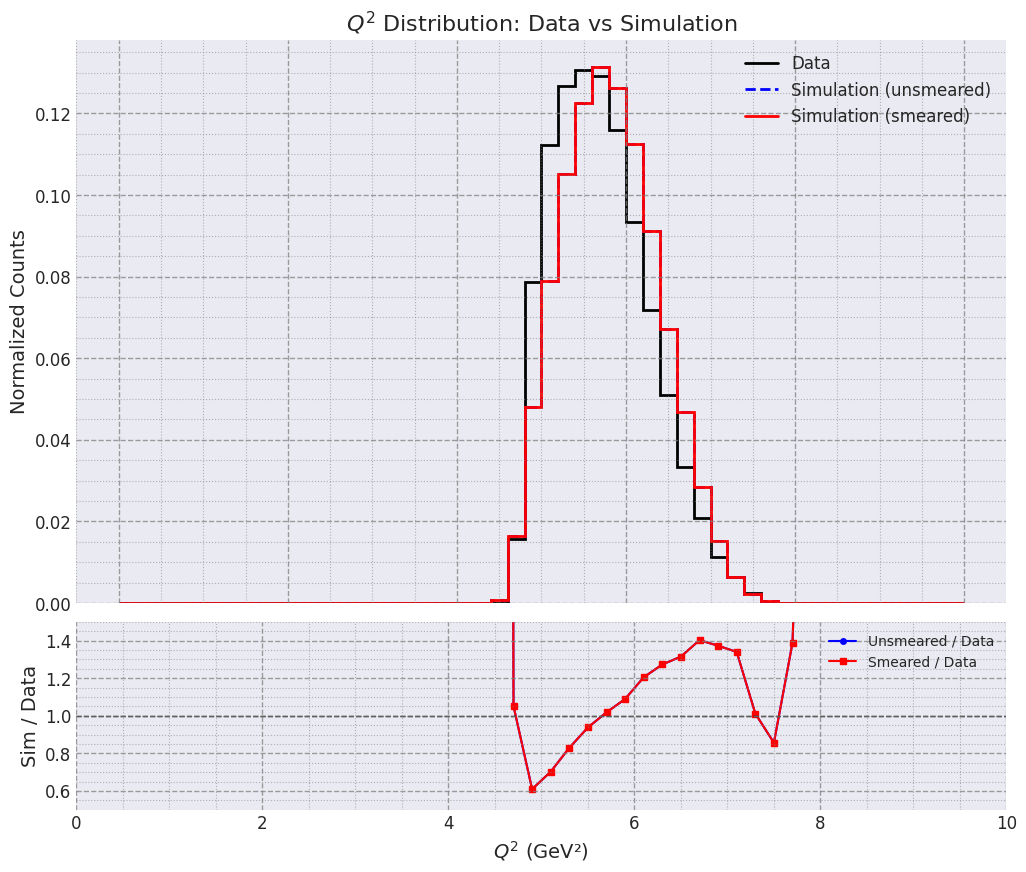


Q2 Statistics:
Data:             mean=5.7188, std=0.5706
Sim (unsmeared):  mean=5.9972, std=0.6230
Sim (smeared):    mean=5.9972, std=0.6230


In [10]:
plot_comparison('Q2', bins=50, range_vals=(0, 10), 
                xlabel=r'$Q^2$ (GeV²)', 
                title=r'$Q^2$ Distribution: Data vs Simulation')

## W Comparison

/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


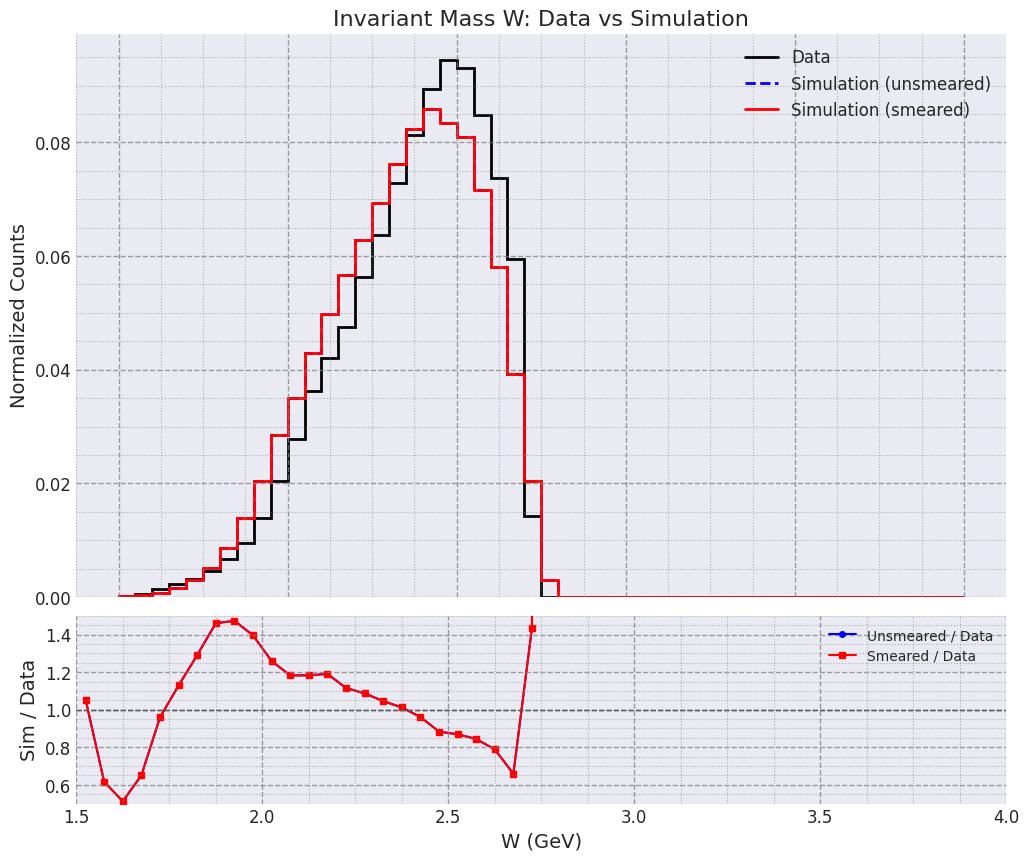


W Statistics:
Data:             mean=2.3666, std=0.2216
Sim (unsmeared):  mean=2.2868, std=0.2531
Sim (smeared):    mean=2.2868, std=0.2531


In [11]:
plot_comparison('W', bins=50, range_vals=(1.5, 4.0), 
                xlabel='W (GeV)', 
                title='Invariant Mass W: Data vs Simulation')

## Bjorken x Comparison

/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


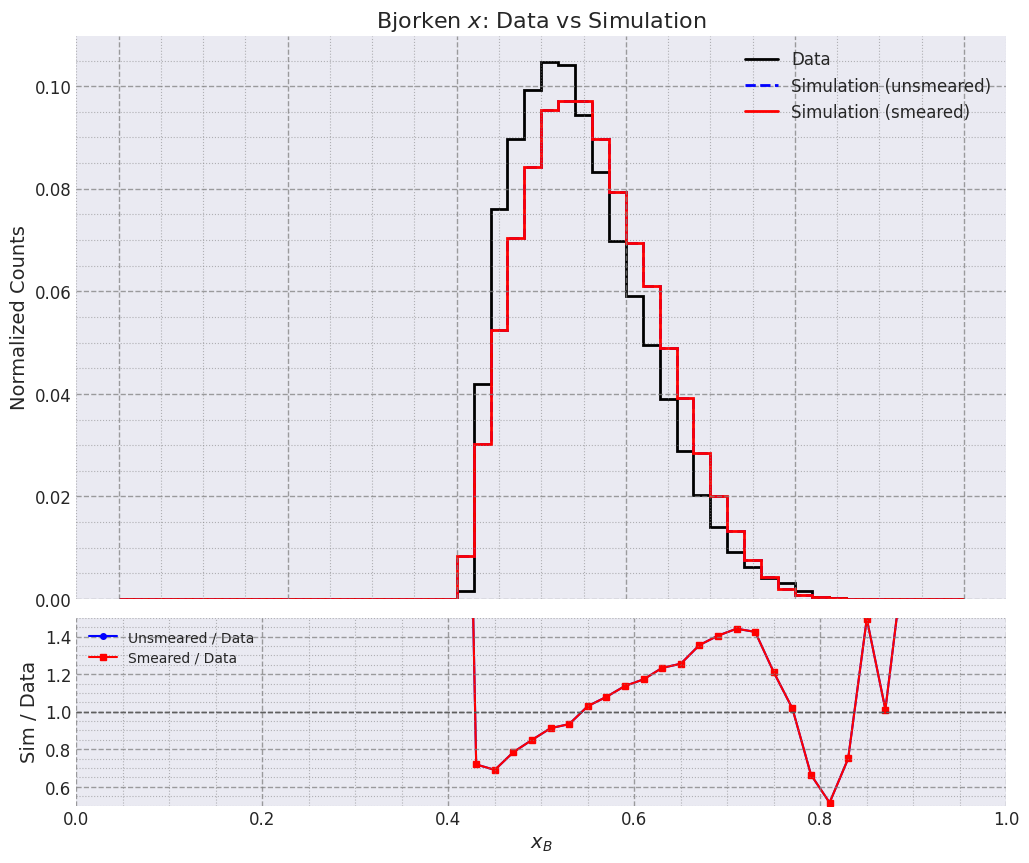


xB Statistics:
Data:             mean=0.5487, std=0.0776
Sim (unsmeared):  mean=0.5806, std=0.0877
Sim (smeared):    mean=0.5806, std=0.0877


In [12]:
plot_comparison('xB', bins=50, range_vals=(0.0, 1.0), 
                xlabel=r'$x_B$', 
                title=r'Bjorken $x$: Data vs Simulation')

## z (Energy Fraction) Comparison

/scratch/singhav/ipykernel_191554/208736187.py:106: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


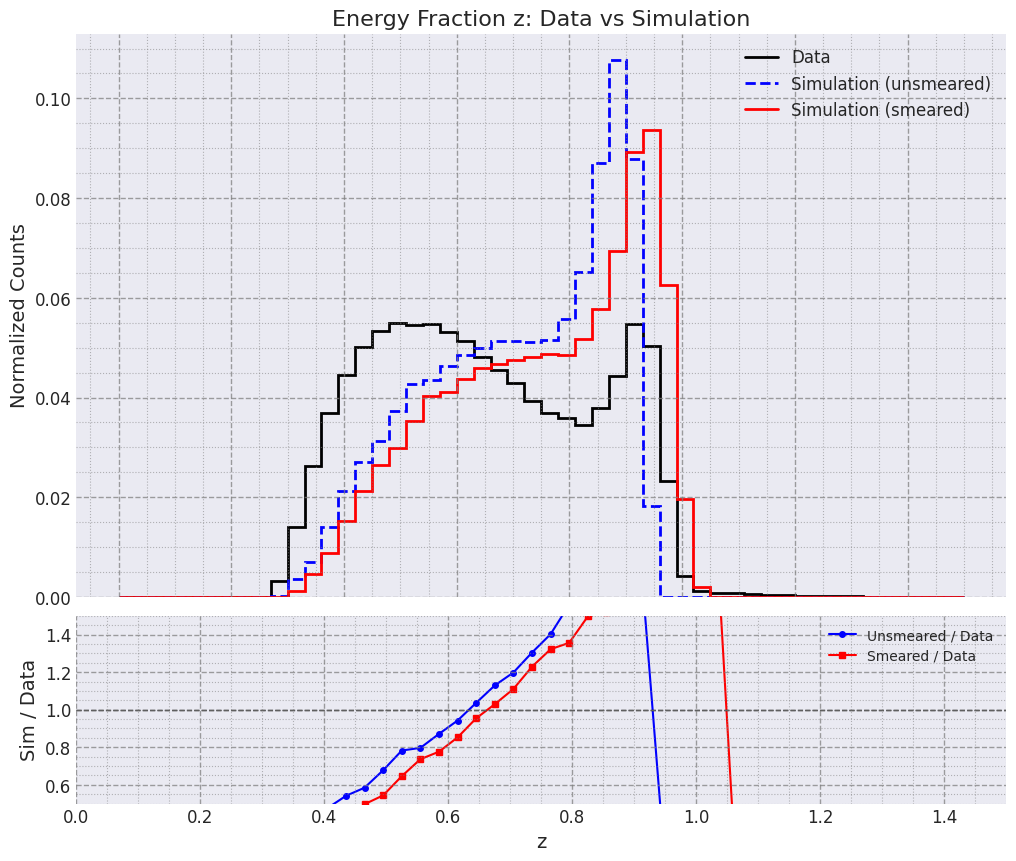


z Statistics:
Data:             mean=0.5666, std=0.1969
Sim (unsmeared):  mean=0.7551, std=0.1417
Sim (smeared):    mean=0.7986, std=0.1508


In [13]:
plot_comparison('z', bins=50, range_vals=(0.0, 1.5), 
                xlabel='z', 
                title='Energy Fraction z: Data vs Simulation')

## 2D Comparison: mpi0 vs mmiss

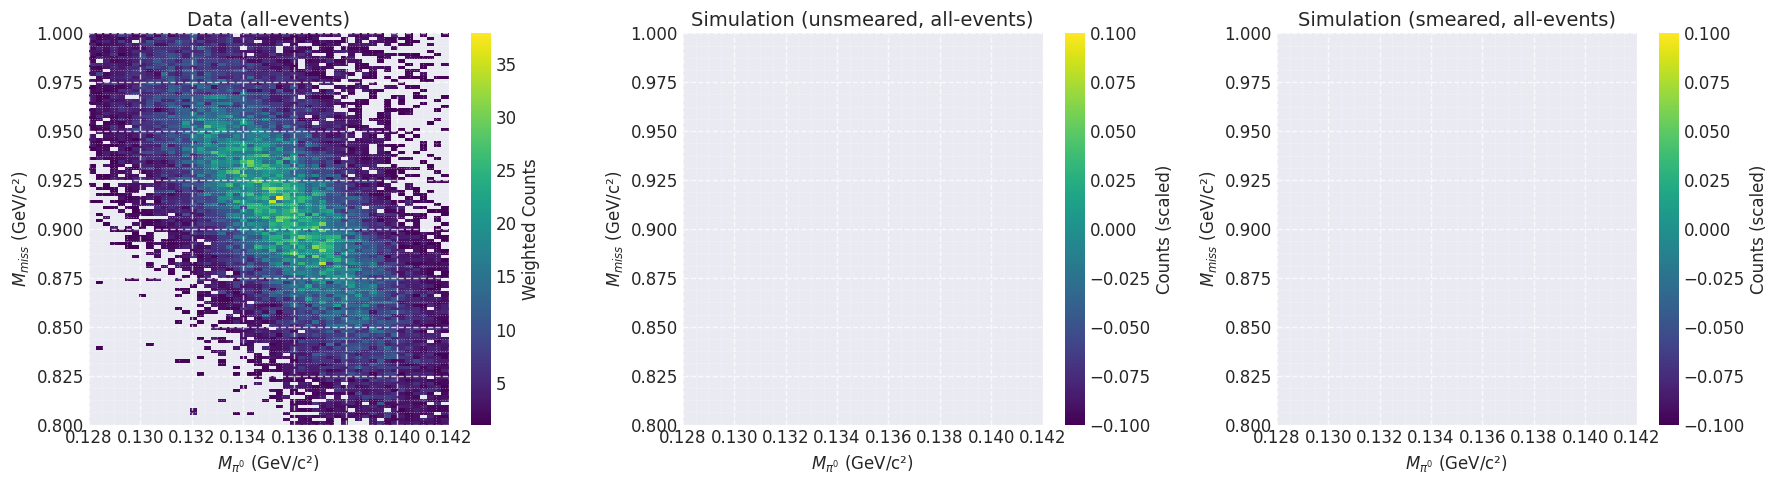

In [14]:
from matplotlib.ticker import AutoMinorLocator

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Use global weights from the weighting cell (all-events or exclusive-weighted mode)
data_weights_2d = data_weights
sim_weights_2d = sim_weights
sim_smeared_weights_2d = sim_smeared_weights

xrange = [FITTER_WINDOWS['mpi0'][0], FITTER_WINDOWS['mpi0'][1]]
yrange = [FITTER_WINDOWS['mmiss'][0], FITTER_WINDOWS['mmiss'][1]]

h1 = axes[0].hist2d(data['mpi0'][data_cut], data['mmiss'][data_cut], 
                     bins=[50, 120], range=[xrange, yrange], 
                     weights=data_weights_2d,
                     cmap='viridis', cmin=1)
axes[0].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[0].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[0].set_title(f'Data ({mode_label})', fontsize=14)
plt.colorbar(h1[3], ax=axes[0], label='Weighted Counts')

h2 = axes[1].hist2d(sim['mpi0'][sim_cut], sim['mmiss'][sim_cut], 
                     bins=[50, 120], range=[xrange, yrange], 
                     weights=sim_weights_2d, cmap='viridis', cmin=1)
# Scale to match data integral
data_integral_2d = np.sum(data_weights_2d)
sim_integral_2d = np.sum(sim_weights_2d)
if sim_integral_2d > 0:
    h2[0][:] = h2[0] * (data_integral_2d / sim_integral_2d)
axes[1].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[1].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[1].set_title(f'Simulation (unsmeared, {mode_label})', fontsize=14)
plt.colorbar(h2[3], ax=axes[1], label='Counts (scaled)')

h3 = axes[2].hist2d(sim_smeared['mpi0'][sim_smeared_cut], sim_smeared['mmiss'][sim_smeared_cut], 
                     bins=[50, 120], range=[xrange, yrange], 
                     weights=sim_smeared_weights_2d, cmap='viridis', cmin=1)
# Scale to match data integral
sim_smeared_integral_2d = np.sum(sim_smeared_weights_2d)
if sim_smeared_integral_2d > 0:
    h3[0][:] = h3[0] * (data_integral_2d / sim_smeared_integral_2d)
axes[2].set_xlabel(r'$M_{\pi^0}$ (GeV/c²)', fontsize=12)
axes[2].set_ylabel(r'$M_{miss}$ (GeV/c²)', fontsize=12)
axes[2].set_title(f'Simulation (smeared, {mode_label})', fontsize=14)
plt.colorbar(h3[3], ax=axes[2], label='Counts (scaled)')

for ax in axes:
    ax.minorticks_on()
    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    ax.set_axisbelow(False)
    ax.grid(True, which='major', linestyle='--', linewidth=1.0, color='white', alpha=0.75, zorder=10)
    ax.grid(True, which='minor', linestyle=':', linewidth=0.7, color='white', alpha=0.45, zorder=10)

plt.tight_layout()
plt.show()

## 2D Comparison (Exclusive): mpgg² vs mmiss and mpgg² vs mpi0

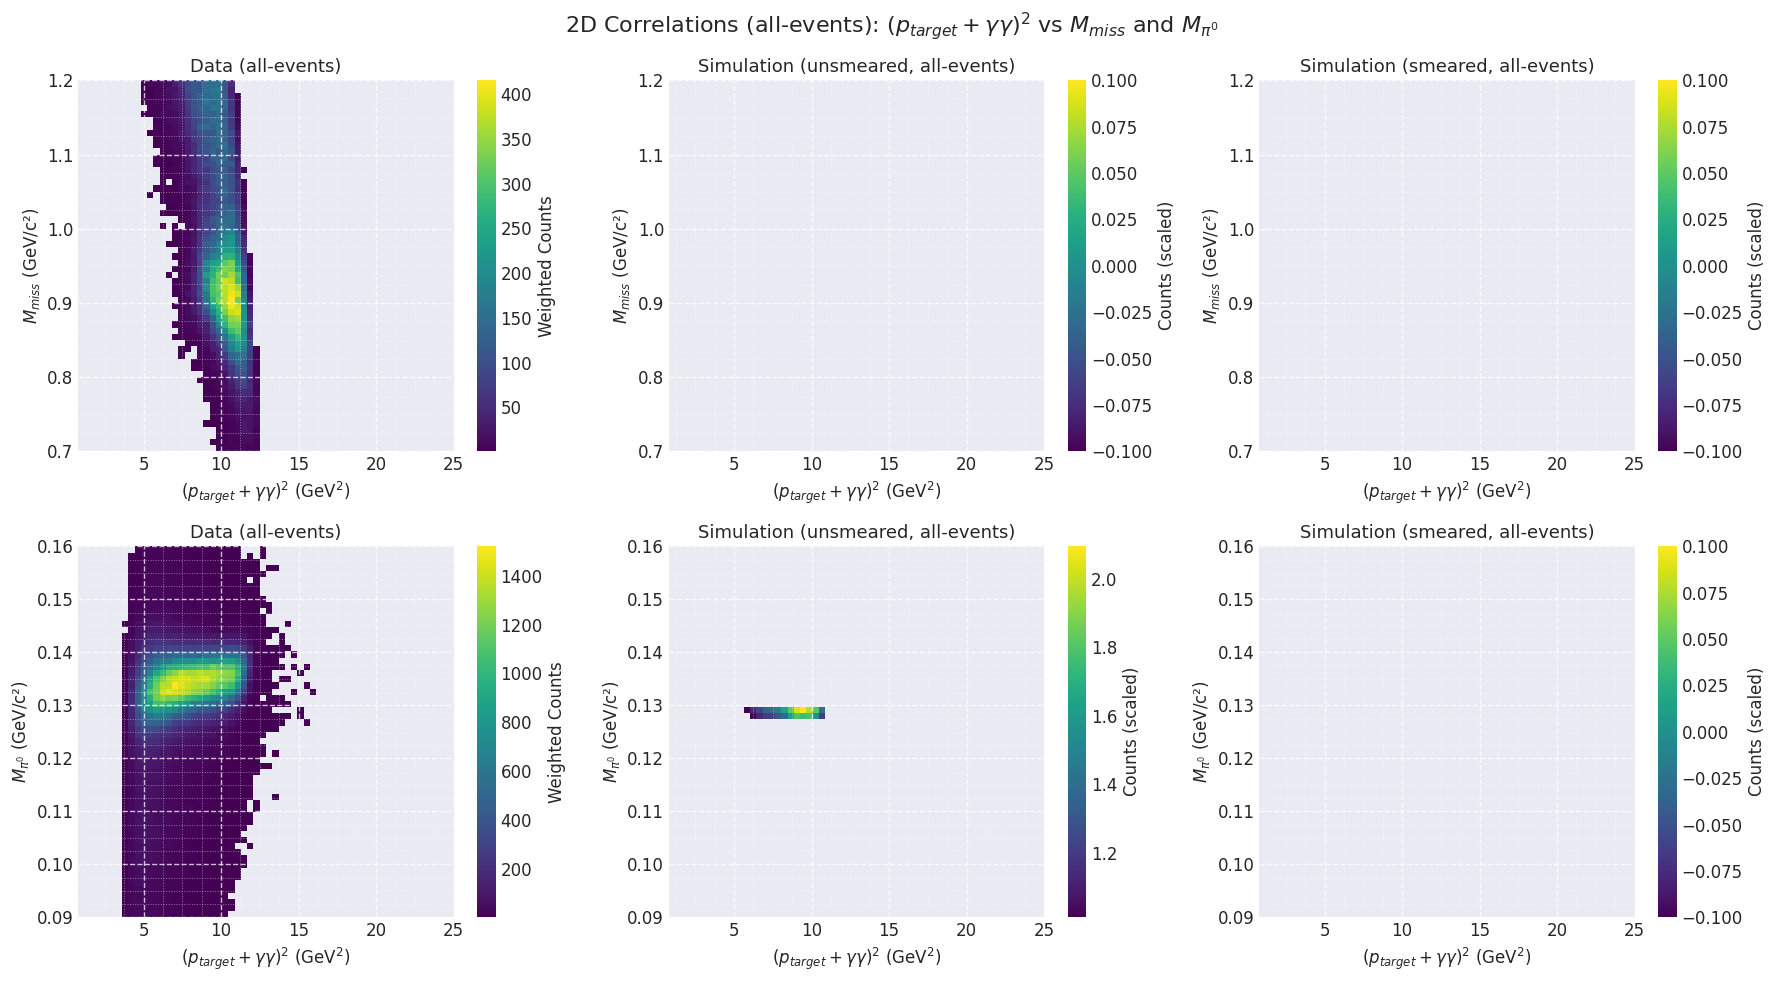

w_mpgg2_energy = 1.000000
Mode entries: data=635828, sim=157189, smeared=157189


In [15]:
from matplotlib.ticker import AutoMinorLocator

# Match C++ configurable factor for mpgg2 energy scaling
w_mpgg2_energy = 1.0
M_P = 0.9382720813  # GeV/c^2

def theta_to_rad(theta_vals):
    if np.nanmax(np.abs(theta_vals)) > 2 * np.pi:
        return np.deg2rad(theta_vals)
    return theta_vals

def compute_mpgg2_from_e_theta(E1, E2, theta_vals, w_energy=1.0):
    theta_rad = theta_to_rad(theta_vals)
    term_4e1e2 = 4.0 * (w_energy * E1) * (w_energy * E2) * np.sin(theta_rad / 2.0) ** 2
    term_2mpesum = 2.0 * M_P * (w_energy * (E1 + E2))
    return M_P**2 + term_4e1e2 + term_2mpesum

def build_mpgg2(sample, sample_name):
    n = len(sample['mpi0']) if ('mpi0' in sample and len(sample['mpi0']) > 0) else 0
    if n == 0:
        return np.array([])

    if ('cluster_e_1' in sample and len(sample['cluster_e_1']) == n and
        'cluster_e_2' in sample and len(sample['cluster_e_2']) == n and
        'theta' in sample and len(sample['theta']) == n):
        return compute_mpgg2_from_e_theta(sample['cluster_e_1'], sample['cluster_e_2'], sample['theta'], w_mpgg2_energy)

    e_sum = None
    for key in ('e_sum', 'pi0_e', 'E_pi0', 'pi0_energy', 'epi0'):
        if key in sample and len(sample[key]) == n:
            e_sum = sample[key]
            break

    if e_sum is None and sample_name == 'sim' and 'sim_e_sum' in globals() and len(sim_e_sum) == n:
        e_sum = sim_e_sum
    if e_sum is None and sample_name == 'sim_smeared' and 'sim_smeared_e_sum' in globals() and len(sim_smeared_e_sum) == n:
        e_sum = sim_smeared_e_sum

    if e_sum is not None and 'mpi0' in sample and len(sample['mpi0']) == n:
        return M_P**2 + (w_mpgg2_energy**2) * (sample['mpi0']**2) + 2.0 * M_P * w_mpgg2_energy * e_sum

    if ('mpgg2' in sample and len(sample['mpgg2']) == n and np.isclose(w_mpgg2_energy, 1.0)):
        return sample['mpgg2']

    print(f"Warning: could not construct mpgg2 for {sample_name}; filling NaN")
    return np.full(n, np.nan)

# Recompute mpgg2 with w_mpgg2_energy scaling
for sample_name, sample in (('data', data), ('sim', sim), ('sim_smeared', sim_smeared)):
    sample['mpgg2'] = build_mpgg2(sample, sample_name)

# Build mode-dependent masks
if APPLY_IS_EXCLUSIVE_SELECTION:
    data_mode_mask = data_cut & (data_excl_factor > 0)
    sim_mode_mask = sim_cut & (sim_excl_factor > 0)
    sim_smeared_mode_mask = sim_smeared_cut & (sim_smeared_excl_factor > 0)
    mode_label_2d = 'exclusive-weighted'
else:
    data_mode_mask = data_cut.copy()
    sim_mode_mask = sim_cut.copy()
    sim_smeared_mode_mask = sim_smeared_cut.copy()
    mode_label_2d = 'all-events'

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

def plot_2d_row(ax_row, yvar, y_label, y_range):
    data_mask = data_mode_mask & np.isfinite(data['mpgg2']) & np.isfinite(data[yvar])
    sim_mask = sim_mode_mask & np.isfinite(sim['mpgg2']) & np.isfinite(sim[yvar])
    sm_mask = sim_smeared_mode_mask & np.isfinite(sim_smeared['mpgg2']) & np.isfinite(sim_smeared[yvar])

    data_w_all = data_weights[data_mask[data_cut]] if np.sum(data_cut) > 0 else np.ones(np.sum(data_mask))
    h1 = ax_row[0].hist2d(
        data['mpgg2'][data_mask], data[yvar][data_mask],
        bins=[60, 60], range=[[0.8, 25.0], y_range],
        weights=data_w_all, cmap='viridis', cmin=1
    )
    ax_row[0].set_xlabel(r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)', fontsize=12)
    ax_row[0].set_ylabel(y_label, fontsize=12)
    ax_row[0].set_title(f'Data ({mode_label_2d})', fontsize=13)
    plt.colorbar(h1[3], ax=ax_row[0], label='Weighted Counts')

    sim_w_all = sim_weights[sim_mask[sim_cut]] if np.sum(sim_cut) > 0 else np.ones(np.sum(sim_mask))
    h2 = ax_row[1].hist2d(
        sim['mpgg2'][sim_mask], sim[yvar][sim_mask],
        bins=[60, 60], range=[[0.8, 25.0], y_range],
        weights=sim_w_all, cmap='viridis', cmin=1
    )
    data_int = np.sum(data_w_all)
    sim_int = np.sum(sim_w_all)
    if sim_int > 0:
        h2[0][:] = h2[0] * (data_int / sim_int)
    ax_row[1].set_xlabel(r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)', fontsize=12)
    ax_row[1].set_ylabel(y_label, fontsize=12)
    ax_row[1].set_title(f'Simulation (unsmeared, {mode_label_2d})', fontsize=13)
    plt.colorbar(h2[3], ax=ax_row[1], label='Counts (scaled)')

    sm_w_all = sim_smeared_weights[sm_mask[sim_smeared_cut]] if np.sum(sim_smeared_cut) > 0 else np.ones(np.sum(sm_mask))
    h3 = ax_row[2].hist2d(
        sim_smeared['mpgg2'][sm_mask], sim_smeared[yvar][sm_mask],
        bins=[60, 60], range=[[0.8, 25.0], y_range],
        weights=sm_w_all, cmap='viridis', cmin=1
    )
    sm_int = np.sum(sm_w_all)
    if sm_int > 0:
        h3[0][:] = h3[0] * (data_int / sm_int)
    ax_row[2].set_xlabel(r'$(p_{target}+\gamma\gamma)^2$ (GeV$^2$)', fontsize=12)
    ax_row[2].set_ylabel(y_label, fontsize=12)
    ax_row[2].set_title(f'Simulation (smeared, {mode_label_2d})', fontsize=13)
    plt.colorbar(h3[3], ax=ax_row[2], label='Counts (scaled)')

plot_2d_row(axes[0], 'mmiss', r'$M_{miss}$ (GeV/c²)', [0.7, 1.2])
plot_2d_row(axes[1], 'mpi0', r'$M_{\pi^0}$ (GeV/c²)', [0.09, 0.16])

for row in axes:
    for ax in row:
        ax.minorticks_on()
        ax.xaxis.set_minor_locator(AutoMinorLocator(4))
        ax.yaxis.set_minor_locator(AutoMinorLocator(4))
        ax.set_axisbelow(False)
        ax.grid(True, which='major', linestyle='--', linewidth=1.0, color='white', alpha=0.75, zorder=10)
        ax.grid(True, which='minor', linestyle=':', linewidth=0.7, color='white', alpha=0.45, zorder=10)

plt.suptitle(f'2D Correlations ({mode_label_2d}): $(p_{{target}}+\gamma\gamma)^2$ vs $M_{{miss}}$ and $M_{{\pi^0}}$', fontsize=16)
plt.tight_layout()
plt.show()

print(f"w_mpgg2_energy = {w_mpgg2_energy:.6f}")
print(f"Mode entries: data={np.sum(data_mode_mask)}, sim={np.sum(sim_mode_mask)}, smeared={np.sum(sim_smeared_mode_mask)}")

## Resolution Effects: Smeared vs Unsmeared Simulation

In [16]:
def plot_resolution_effect(var_name, bins=50, range_vals=None, xlabel=None):
    """
    Plot the difference between smeared and unsmeared simulation to visualize resolution effects
    Uses SIMC full_weight for proper event weighting
    """
    fig, ax = plt.subplots(figsize=(12, 6))
    
    sim_vals = sim[var_name][sim_cut]
    sim_smeared_vals = sim_smeared[var_name][sim_smeared_cut]
    
    sim_weights = sim['weight'][sim_cut] if len(sim['weight']) > 0 else np.ones(len(sim_vals))
    sim_smeared_weights = sim_smeared['weight'][sim_smeared_cut] if len(sim_smeared['weight']) > 0 else np.ones(len(sim_smeared_vals))
    
    if range_vals is None:
        valid = sim_vals[sim_vals > -900]
        if len(valid) > 0:
            p1, p99 = np.percentile(valid, [1, 99])
            range_vals = (p1, p99)
    
    ax.hist(sim_vals, bins=bins, range=range_vals, weights=sim_weights,
            histtype='step', color='blue', linewidth=2, label='Unsmeared', density=True)
    ax.hist(sim_smeared_vals, bins=bins, range=range_vals, weights=sim_smeared_weights,
            histtype='step', color='red', linewidth=2, label='Smeared', density=True)
    
    ax.set_xlabel(xlabel if xlabel else var_name, fontsize=14)
    ax.set_ylabel('Normalized Counts', fontsize=14)
    ax.set_title(f'Resolution Effect on {var_name}', fontsize=16)
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Calculate resolution
    sigma_unsmeared = np.std(sim_vals)
    sigma_smeared = np.std(sim_smeared_vals)
    print(f"\n{var_name} Resolution:")
    print(f"σ (unsmeared): {sigma_unsmeared:.4f}")
    print(f"σ (smeared):   {sigma_smeared:.4f}")
    print(f"Additional smearing: {np.sqrt(max(0, sigma_smeared**2 - sigma_unsmeared**2)):.4f}")


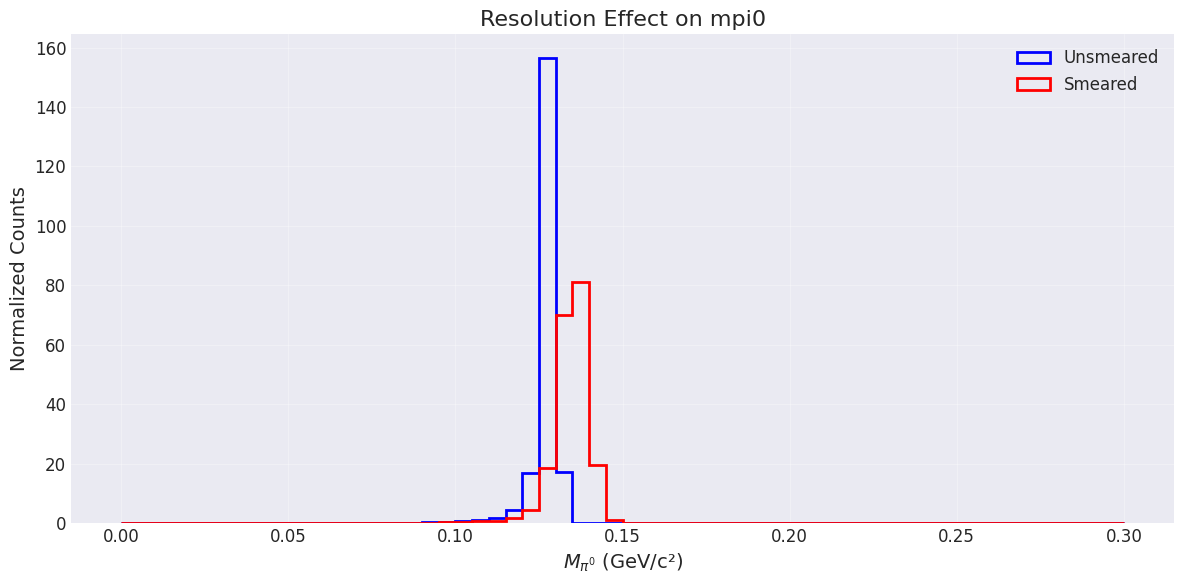


mpi0 Resolution:
σ (unsmeared): 0.0048
σ (smeared):   0.0061
Additional smearing: 0.0037


In [17]:
plot_resolution_effect('mpi0', bins=60, range_vals=(0.0, 0.3), xlabel=r'$M_{\pi^0}$ (GeV/c²)')


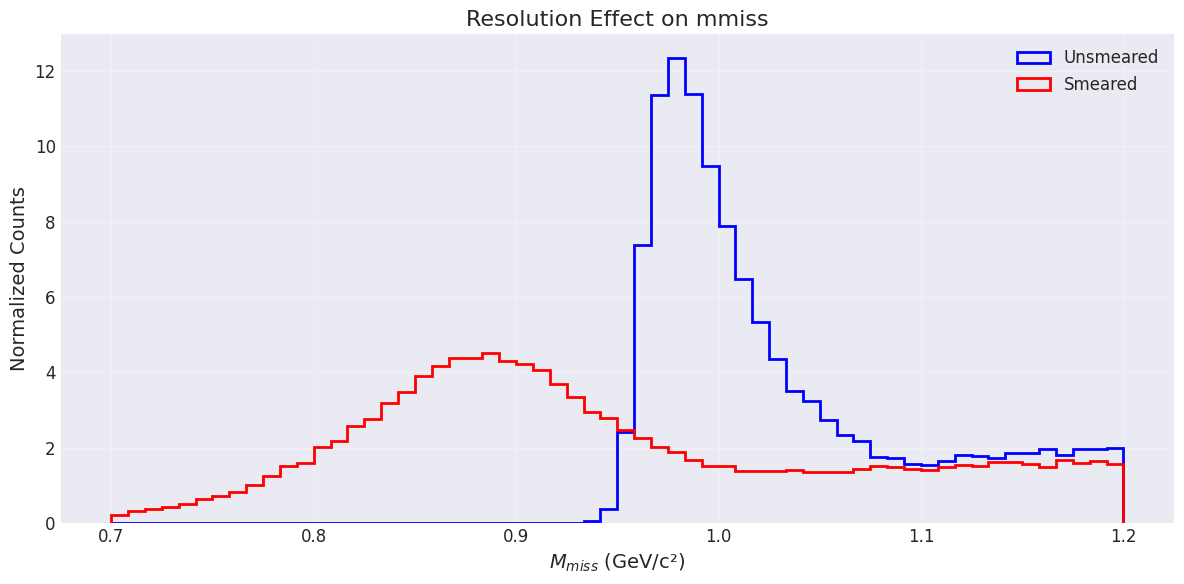


mmiss Resolution:
σ (unsmeared): 0.2745
σ (smeared):   0.3080
Additional smearing: 0.1398


In [18]:
plot_resolution_effect('mmiss', bins=60, range_vals=(0.7, 1.2), xlabel=r'$M_{miss}$ (GeV/c²)')


## Cluster Energy Distribution on Calorimeter Face

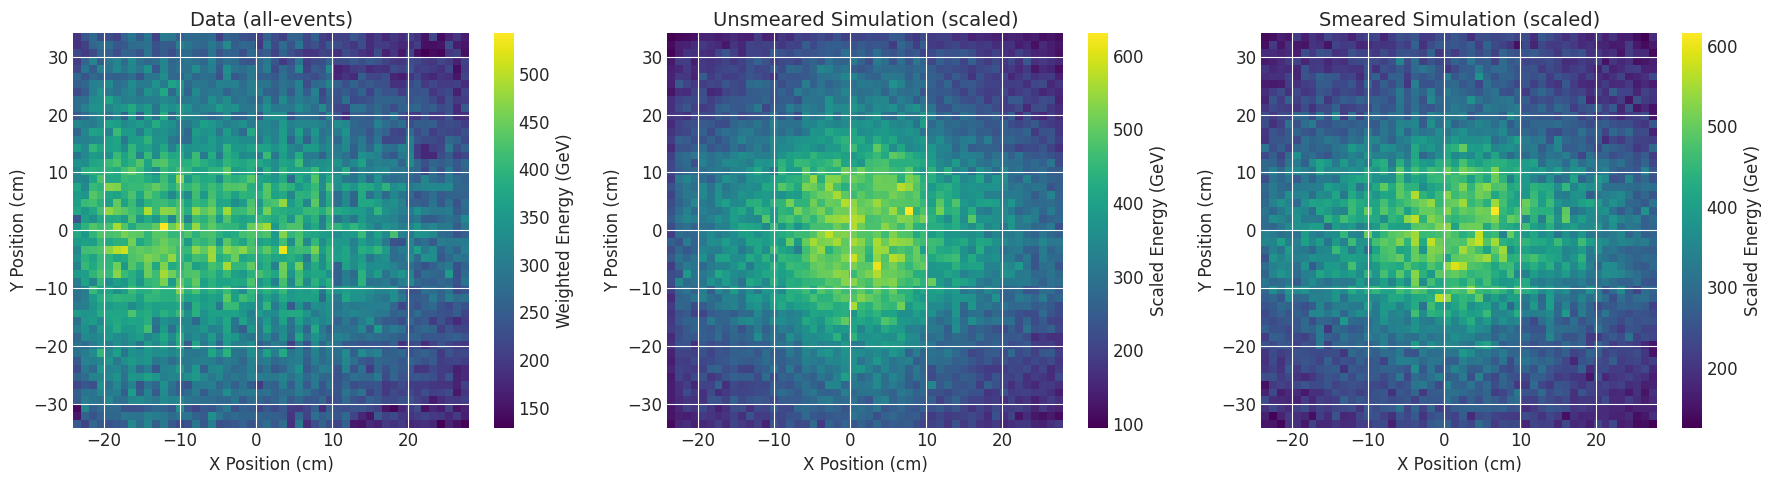


Cluster Energy Distribution Summary:
Mode: all-events
Data total weighted energy: 767102.55 GeV
Unsmeared sim total energy: 869445.31 GeV (scaled by 0.8823)
Smeared sim total energy: 696975.12 GeV (scaled by 1.1006)

Data clusters: 1271656 (from 635828 events, 2 photons each)
Unsmeared sim clusters: 421354 (from 210677 events)
Smeared sim clusters: 314378 (from 157189 events)


In [19]:
# Visualize cluster energy distribution over the calorimeter face
# This shows how smearing affects the energy distribution

# For data: use both photon clusters, weight with global mode (all-events or exclusive-weighted)
# For simulation: use all clusters from clust_X, clust_Y, clust_E arrays

# Data: combine both photon clusters
data_clust_x = np.concatenate([data['cluster_x_1'][data_cut], data['cluster_x_2'][data_cut]])
data_clust_y = np.concatenate([data['cluster_y_1'][data_cut], data['cluster_y_2'][data_cut]])
data_clust_e = np.concatenate([data['cluster_e_1'][data_cut], data['cluster_e_2'][data_cut]])

# Duplicate per-event weights for both clusters
data_clust_weights = np.concatenate([data_weights, data_weights])

# Simulation unsmeared: apply mmiss != -999 cut, then flatten cluster arrays
sim_mmiss_cut = sim['mmiss'] != -999
import awkward as ak
sim_clust_x_jagged = sim['clust_X'][sim_mmiss_cut]
sim_clust_y_jagged = sim['clust_Y'][sim_mmiss_cut]
sim_clust_e_jagged = sim['clust_E'][sim_mmiss_cut]

sim_clust_x = ak.flatten(sim_clust_x_jagged).to_numpy()
sim_clust_y = ak.flatten(sim_clust_y_jagged).to_numpy()
sim_clust_e = ak.flatten(sim_clust_e_jagged).to_numpy()

# Smeared simulation: flatten cluster arrays for all events
sim_smeared_clust_x_jagged = sim_smeared['clust_X'][sim_smeared_cut]
sim_smeared_clust_y_jagged = sim_smeared['clust_Y'][sim_smeared_cut]
sim_smeared_clust_e_jagged = sim_smeared['clust_E'][sim_smeared_cut]

sim_smeared_clust_x = ak.flatten(sim_smeared_clust_x_jagged).to_numpy()
sim_smeared_clust_y = ak.flatten(sim_smeared_clust_y_jagged).to_numpy()
sim_smeared_clust_e = ak.flatten(sim_smeared_clust_e_jagged).to_numpy()

# Create 2D histograms for energy distribution
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x_bins = 50
y_bins = 50

# Data
h_data, xedges, yedges = np.histogram2d(
    data_clust_x, data_clust_y, bins=[x_bins, y_bins],
    weights=data_clust_e * data_clust_weights
)
im1 = axes[0].imshow(h_data.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[0].set_title(f'Data ({mode_label})', fontsize=14)
axes[0].set_xlabel('X Position (cm)', fontsize=12)
axes[0].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im1, ax=axes[0], label='Weighted Energy (GeV)')

# Unsmeared simulation - scale to match data total
data_total_energy = np.sum(data_clust_e * data_clust_weights)
h_sim, _, _ = np.histogram2d(
    sim_clust_x, sim_clust_y, bins=[x_bins, y_bins],
    weights=sim_clust_e
)
sim_total_energy = np.sum(sim_clust_e)
scale_factor = data_total_energy / sim_total_energy if sim_total_energy > 0 else 1.0
h_sim_scaled = h_sim * scale_factor

im2 = axes[1].imshow(h_sim_scaled.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[1].set_title('Unsmeared Simulation (scaled)', fontsize=14)
axes[1].set_xlabel('X Position (cm)', fontsize=12)
axes[1].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im2, ax=axes[1], label='Scaled Energy (GeV)')

# Smeared simulation - scale to match data total
h_sim_smeared, _, _ = np.histogram2d(
    sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins],
    weights=sim_smeared_clust_e
)
sim_smeared_total_energy = np.sum(sim_smeared_clust_e)
scale_factor_smeared = data_total_energy / sim_smeared_total_energy if sim_smeared_total_energy > 0 else 1.0
h_sim_smeared_scaled = h_sim_smeared * scale_factor_smeared

im3 = axes[2].imshow(h_sim_smeared_scaled.T, origin='lower', aspect='auto',
                     extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                     cmap='viridis', interpolation='nearest')
axes[2].set_title('Smeared Simulation (scaled)', fontsize=14)
axes[2].set_xlabel('X Position (cm)', fontsize=12)
axes[2].set_ylabel('Y Position (cm)', fontsize=12)
plt.colorbar(im3, ax=axes[2], label='Scaled Energy (GeV)')

plt.tight_layout()
plt.show()

print("\nCluster Energy Distribution Summary:")
print(f"Mode: {mode_label}")
print(f"Data total weighted energy: {data_total_energy:.2f} GeV")
print(f"Unsmeared sim total energy: {sim_total_energy:.2f} GeV (scaled by {scale_factor:.4f})")
print(f"Smeared sim total energy: {sim_smeared_total_energy:.2f} GeV (scaled by {scale_factor_smeared:.4f})")
print(f"\nData clusters: {len(data_clust_x)} (from {np.sum(data_cut)} events, 2 photons each)")
print(f"Unsmeared sim clusters: {len(sim_clust_x)} (from {np.sum(sim_mmiss_cut)} events)")
print(f"Smeared sim clusters: {len(sim_smeared_clust_x)} (from {np.sum(sim_smeared_cut)} events)")

ValueError: operands could not be broadcast together with shapes (157189,) (210677,) 

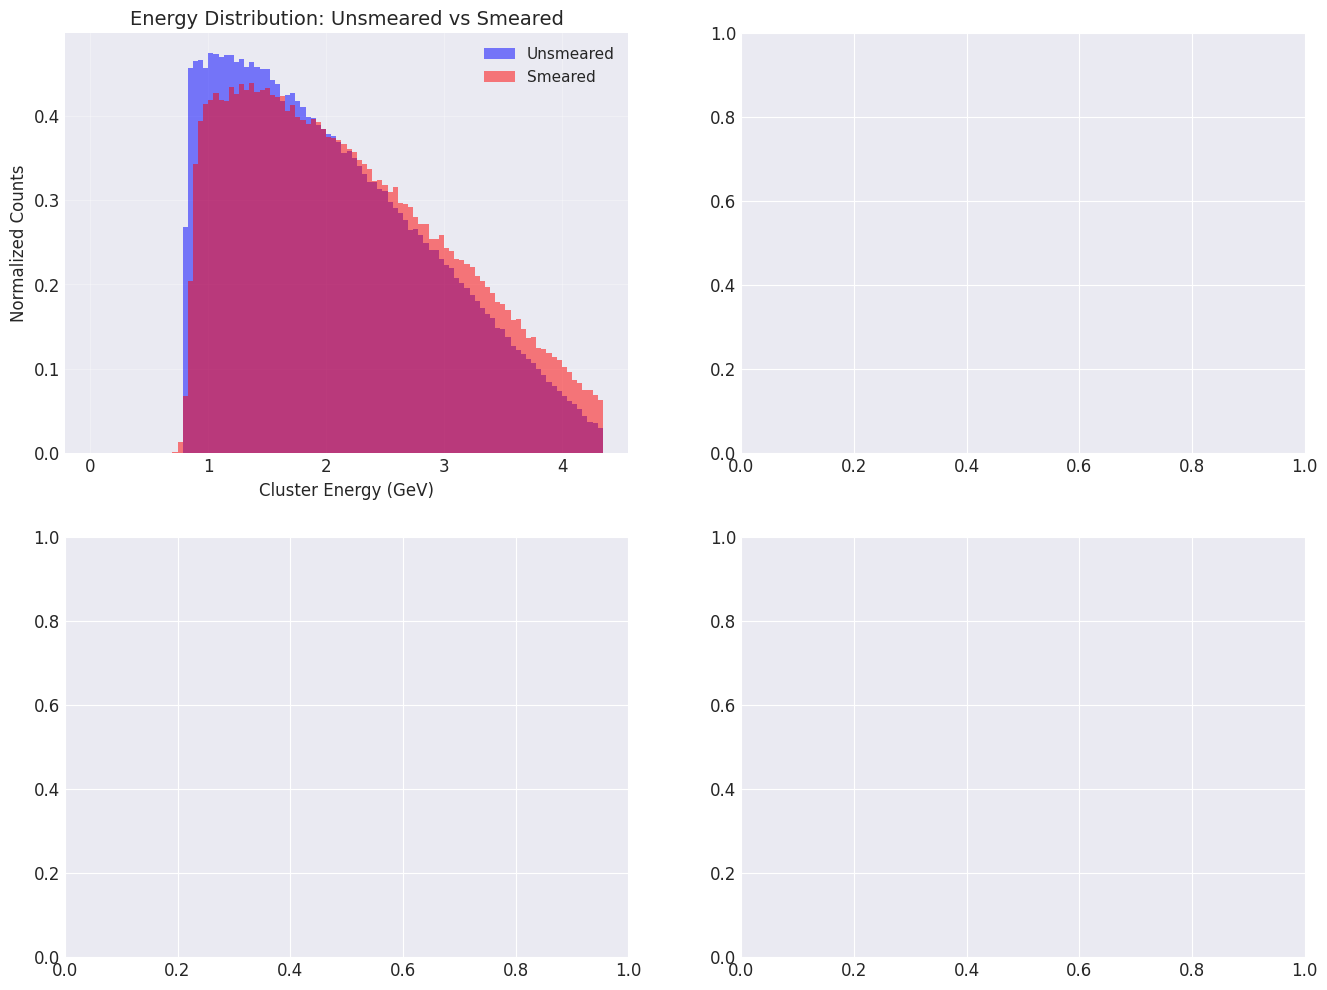

In [20]:
# Compare unsmeared vs smeared energy distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Energy histogram comparison
ax1 = axes[0, 0]
bins_e = 100
range_e = (0, np.percentile(np.concatenate([sim_clust_e, sim_smeared_clust_e]), 99))

ax1.hist(sim_clust_e, bins=bins_e, range=range_e, alpha=0.5, 
         label='Unsmeared', color='blue', density=True)
ax1.hist(sim_smeared_clust_e, bins=bins_e, range=range_e, alpha=0.5,
         label='Smeared', color='red', density=True)
ax1.set_xlabel('Cluster Energy (GeV)', fontsize=12)
ax1.set_ylabel('Normalized Counts', fontsize=12)
ax1.set_title('Energy Distribution: Unsmeared vs Smeared', fontsize=14)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# 2. Energy difference histogram
ax2 = axes[0, 1]
# For this, we need to match clusters by event - using the mean energy per event
sim_mean_e = np.array([np.mean(e) if len(e) > 0 else 0 for e in sim_clust_e_jagged])
sim_smeared_mean_e = np.array([np.mean(e) if len(e) > 0 else 0 for e in sim_smeared_clust_e_jagged])
energy_diff = sim_smeared_mean_e - sim_mean_e

ax2.hist(energy_diff, bins=50, color='purple', alpha=0.7)
ax2.axvline(x=0, color='black', linestyle='--', linewidth=2)
ax2.axvline(x=np.mean(energy_diff), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {np.mean(energy_diff):.4f} GeV')
ax2.set_xlabel('Energy Difference (Smeared - Unsmeared) [GeV]', fontsize=12)
ax2.set_ylabel('Counts', fontsize=12)
ax2.set_title('Mean Energy Difference per Event', fontsize=14)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# 3. Position-dependent energy difference (2D map)
ax3 = axes[1, 0]
# Calculate mean energies in position bins
x_bins = 30
y_bins = 30

h_unsm, xedges, yedges = np.histogram2d(sim_clust_x, sim_clust_y, bins=[x_bins, y_bins])
h_unsm_e, _, _ = np.histogram2d(sim_clust_x, sim_clust_y, bins=[x_bins, y_bins], weights=sim_clust_e)
mean_e_unsm = np.divide(h_unsm_e, h_unsm, out=np.zeros_like(h_unsm_e), where=h_unsm!=0)

h_sm, _, _ = np.histogram2d(sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins])
h_sm_e, _, _ = np.histogram2d(sim_smeared_clust_x, sim_smeared_clust_y, bins=[x_bins, y_bins], weights=sim_smeared_clust_e)
mean_e_sm = np.divide(h_sm_e, h_sm, out=np.zeros_like(h_sm_e), where=h_sm!=0)

diff_map = mean_e_sm - mean_e_unsm
im = ax3.imshow(diff_map.T, origin='lower', aspect='auto',
                extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                cmap='RdBu_r', interpolation='nearest')
ax3.set_xlabel('X Position (cm)', fontsize=12)
ax3.set_ylabel('Y Position (cm)', fontsize=12)
ax3.set_title('Mean Energy Difference Map\n(Smeared - Unsmeared)', fontsize=14)
plt.colorbar(im, ax=ax3, label='Energy Difference (GeV)')

# 4. Energy resolution as function of position
ax4 = axes[1, 1]
# Calculate resolution (std/mean) in position bins
resolution_map = np.zeros((x_bins, y_bins))
for i in range(x_bins):
    for j in range(y_bins):
        mask_unsm = ((sim_clust_x >= xedges[i]) & (sim_clust_x < xedges[i+1]) &
                     (sim_clust_y >= yedges[j]) & (sim_clust_y < yedges[j+1]))
        mask_sm = ((sim_smeared_clust_x >= xedges[i]) & (sim_smeared_clust_x < xedges[i+1]) &
                   (sim_smeared_clust_y >= yedges[j]) & (sim_smeared_clust_y < yedges[j+1]))
        
        if np.sum(mask_sm) > 10:  # Need sufficient statistics
            e_sm = sim_smeared_clust_e[mask_sm]
            mean_e = np.mean(e_sm)
            std_e = np.std(e_sm)
            if mean_e > 0:
                resolution_map[i, j] = std_e / mean_e
            else:
                resolution_map[i, j] = 0
        else:
            resolution_map[i, j] = 0

im2 = ax4.imshow(resolution_map.T, origin='lower', aspect='auto',
                 extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
                 cmap='viridis', interpolation='nearest', vmin=0, vmax=np.percentile(resolution_map[resolution_map>0], 95))
ax4.set_xlabel('X Position (cm)', fontsize=12)
ax4.set_ylabel('Y Position (cm)', fontsize=12)
ax4.set_title('Energy Resolution Map (σ/E)\nSmeared Simulation', fontsize=14)
plt.colorbar(im2, ax=ax4, label='σ/E')

plt.tight_layout()
plt.show()

print("\n=== Energy Distribution Comparison ===")
print(f"Unsmeared simulation:")
print(f"  Mean cluster energy: {np.mean(sim_clust_e):.4f} GeV")
print(f"  Std cluster energy: {np.std(sim_clust_e):.4f} GeV")
print(f"  Energy resolution (σ/E): {np.std(sim_clust_e)/np.mean(sim_clust_e):.4f}")

print(f"\nSmeared simulation:")
print(f"  Mean cluster energy: {np.mean(sim_smeared_clust_e):.4f} GeV")
print(f"  Std cluster energy: {np.std(sim_smeared_clust_e):.4f} GeV")
print(f"  Energy resolution (σ/E): {np.std(sim_smeared_clust_e)/np.mean(sim_smeared_clust_e):.4f}")

print(f"\nMean event-level energy difference: {np.mean(energy_diff):.4f} ± {np.std(energy_diff):.4f} GeV")
print(f"RMS energy difference: {np.sqrt(np.mean(energy_diff**2)):.4f} GeV")

## Summary Statistics Table

In [ ]:
# Create summary table
summary_vars = ['mpi0', 'mmiss', 'mpgg2', 'Q2', 'W', 'xB', 'z']
summary_data = []

for var in summary_vars:
    if var in data and var in sim and var in sim_smeared:
        data_vals = data[var][data_cut]
        sim_vals = sim[var][sim_cut]
        sim_smeared_vals = sim_smeared[var][sim_smeared_cut]
        
        # Filter sentinel values
        data_vals = data_vals[data_vals > -900]
        sim_vals = sim_vals[sim_vals > -900]
        sim_smeared_vals = sim_smeared_vals[sim_smeared_vals > -900]
        
        summary_data.append({
            'Variable': var,
            'Data Mean': f"{np.mean(data_vals):.4f}",
            'Data Std': f"{np.std(data_vals):.4f}",
            'Sim Mean': f"{np.mean(sim_vals):.4f}",
            'Sim Std': f"{np.std(sim_vals):.4f}",
            'Smeared Mean': f"{np.mean(sim_smeared_vals):.4f}",
            'Smeared Std': f"{np.std(sim_smeared_vals):.4f}"
        })

summary_df = pd.DataFrame(summary_data)
print("\n=== Summary Statistics ===")
print(summary_df.to_string(index=False))


=== Summary Statistics ===
Variable Data Mean Data Std Sim Mean Sim Std Smeared Mean Smeared Std
    mpi0    0.1149   0.0529   0.1263  0.0053       0.1271      0.0195
   mmiss    1.6127   0.3918   1.2537  0.2813       1.2072      0.4216
   mpgg2    6.7611   2.0451   8.6407  1.6376       8.6897      1.9991
      Q2    5.7149   0.5707   5.9969  0.6232       5.9969      0.6232
       W    2.3673   0.2217   2.2865  0.2536       2.2865      0.2536
      xB    0.5484   0.0776   0.5806  0.0879       0.5806      0.0879
       z    0.5608   0.1952   0.7434  0.1462       0.7481      0.1827


## Chi-Square Goodness of Fit

In [ ]:
def calculate_chi2_consistent(data_vals, sim_vals, bins, range_vals, data_weights=None, sim_weights=None):
    """
    Chi2 aligned with nps_sim_smearing_new.C style:
      - weighted histograms
      - sim scaled to data integral
      - variance = err_sim^2 + err_data^2 with fallback max(1, s+d)
    """
    data_counts, bin_edges = np.histogram(data_vals, bins=bins, range=range_vals, weights=data_weights)
    sim_counts, _ = np.histogram(sim_vals, bins=bin_edges, weights=sim_weights)

    # Weighted-bin statistical errors from sum of squared weights
    data_w2 = np.histogram(data_vals, bins=bin_edges, weights=(data_weights**2 if data_weights is not None else None))[0]
    sim_w2 = np.histogram(sim_vals, bins=bin_edges, weights=(sim_weights**2 if sim_weights is not None else None))[0]

    data_integral = np.sum(data_counts)
    sim_integral = np.sum(sim_counts)
    if sim_integral > 0 and data_integral > 0:
        scale = data_integral / sim_integral
        sim_counts = sim_counts * scale
        sim_w2 = sim_w2 * (scale**2)

    chi2 = 0.0
    n_informative = 0
    for d, s, ed2, es2 in zip(data_counts, sim_counts, data_w2, sim_w2):
        if d <= 0.0 and s <= 0.0:
            continue
        n_informative += 1
        denom = ed2 + es2
        if denom <= 0.0:
            denom = max(1.0, d + s)
        diff = s - d
        chi2 += (diff * diff) / denom

    # match macro spirit: ndf from informative bins with one normalization constraint
    ndf = max(1, n_informative - 1)
    return chi2, ndf, chi2 / ndf

print("\n=== Chi-Square Goodness of Fit (fitter-consistent windows) ===")
print(f"Mode: {mode_label}")
print("Data weights: pi0_weight * scale * optional(is_exclusive)")
print("Sim  weights: full_weight * optional(is_exclusive)")
print("\nVariable\t\tχ²\t\tNDF\tχ²/NDF (Unsmeared)\tχ²/NDF (Smeared)")
print("-" * 90)

test_vars = [
    ('mpi0', 50, FITTER_WINDOWS['mpi0']),
    ('mmiss', 120, FITTER_WINDOWS['mmiss']),
    ('mpgg2', 50, FITTER_WINDOWS['mpgg2']),
    ('Q2', 50, (0, 10)),
    ('W', 50, (1.5, 4.0)),
    ('xB', 50, (0.0, 1.0)),
    ('z', 50, (0.0, 1.5))
]

for var, bins, range_vals in test_vars:
    if var in data and var in sim and var in sim_smeared:
        data_vals = data[var][data_cut]
        sim_vals = sim[var][sim_cut]
        sim_smeared_vals = sim_smeared[var][sim_smeared_cut]

        chi2_unsm, ndf_unsm, chi2ndf_unsm = calculate_chi2_consistent(
            data_vals, sim_vals, bins, range_vals, data_weights, sim_weights
        )
        chi2_sm, ndf_sm, chi2ndf_sm = calculate_chi2_consistent(
            data_vals, sim_smeared_vals, bins, range_vals, data_weights, sim_smeared_weights
        )

        print(f"{var:15s}\t{chi2_unsm:8.2f}\t{ndf_unsm:4d}\t{chi2ndf_unsm:8.3f}\t\t{chi2ndf_sm:8.3f}")


=== Chi-Square Goodness of Fit ===
Mode: all-events
Data weights: pi0_weight * scale * optional(is_exclusive)
Sim  weights: full_weight * optional(is_exclusive)

Variable		χ²		NDF	χ²/NDF (Unsmeared)	χ²/NDF (Smeared)
------------------------------------------------------------------------------------------
mpi0           	1047922.26	  57	18384.601		34575.396
mmiss          	128443.60	  59	2177.010		 643.835
mpgg2          	55139.86	  57	 967.366		2284.035
Q2             	21963.12	  18	1220.174		1220.174
W              	3277772.33	  25	131110.893		131110.893
xB             	21232.83	  26	 816.647		 816.647
z              	87326.91	  41	2129.925		7949.457


## 1D Ratio: $\frac{4E_1E_2\sin^2(\theta/2)}{2M_p(E_1+E_2)}$

In [ ]:
# # 1D distribution of ratio: [4 E1 E2 sin^2(theta/2)] / [2 M_p (E1 + E2)]
# M_P = 0.938272  # GeV/c^2

# # Data arrays after standard event selection
# E1 = data['cluster_e_1'][data_cut]
# E2 = data['cluster_e_2'][data_cut]
# theta = data['theta'][data_cut]

# # Convert theta to radians if needed (heuristic: values significantly larger than 2π are in degrees)
# if np.nanmax(np.abs(theta)) > 2 * np.pi:
#     theta_rad = np.deg2rad(theta)
#     theta_unit = 'deg'
# else:
#     theta_rad = theta
#     theta_unit = 'rad'

# numerator = 4.0 * E1 * E2 * np.sin(theta_rad / 2.0) ** 2
# denominator = 2.0 * M_P * (E1 + E2)

# ratio = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan, dtype=float), where=denominator != 0)

# # Use the same data weighting convention as other 1D data plots
# base_weight = data['weight'][data_cut] if len(data['weight']) > 0 else np.ones(np.sum(data_cut))
# scale_factor = data['scale'][data_cut] if len(data['scale']) > 0 else np.ones(np.sum(data_cut))
# is_excl = data['is_exclusive'][data_cut] if len(data['is_exclusive']) > 0 else np.ones(np.sum(data_cut))
# ratio_weights = base_weight * scale_factor * is_excl

# valid = np.isfinite(ratio) & (ratio > 0)
# ratio_valid = ratio[valid]
# weights_valid = ratio_weights[valid]

# if len(ratio_valid) == 0:
#     print('No valid events for ratio plot.')
# else:
#     p1, p99 = np.percentile(ratio_valid, [1, 99])

#     plt.figure(figsize=(10, 6))
#     plt.hist(ratio_valid, bins=120, range=(p1, p99), weights=weights_valid,
#              histtype='step', linewidth=2, color='purple', density=True)
#     plt.xlabel(r'$\frac{4E_1E_2\sin^2(\theta/2)}{2M_p(E_1+E_2)}$', fontsize=14)
#     plt.ylabel('Normalized Counts', fontsize=14)
#     plt.title('1D Ratio Distribution', fontsize=16)
#     plt.grid(True, alpha=0.3)
#     plt.tight_layout()
#     plt.show()

#     weighted_mean = np.average(ratio_valid, weights=weights_valid)
#     weighted_std = np.sqrt(np.average((ratio_valid - weighted_mean) ** 2, weights=weights_valid))

#     print('=== Ratio Summary ===')
#     print(f'Theta interpreted as: {theta_unit}')
#     print(f'Entries used: {len(ratio_valid)} / {len(ratio)}')
#     print(f'Weighted mean: {weighted_mean:.6f}')
#     print(f'Weighted std:  {weighted_std:.6f}')


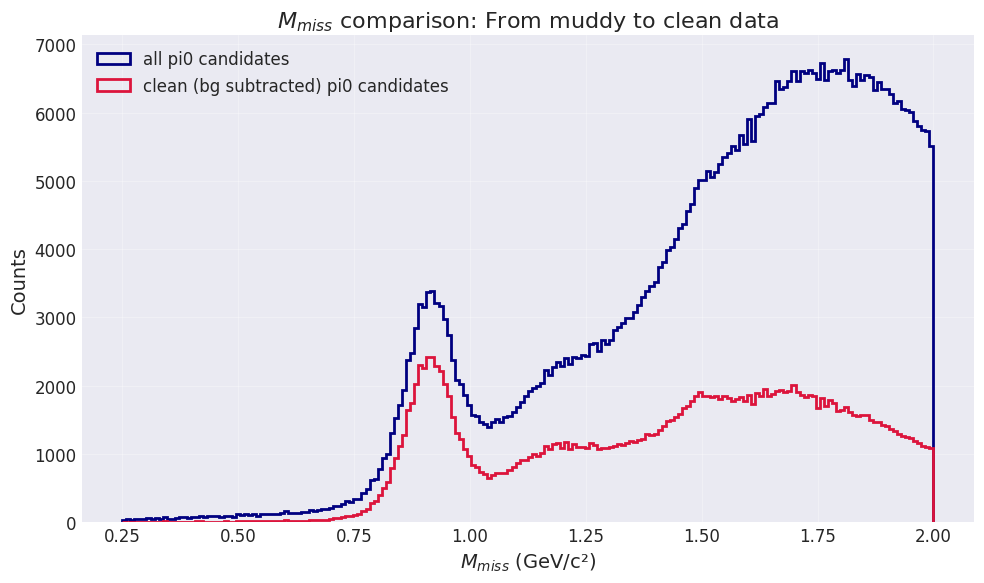

In [24]:
# Overlay for ROOT-style histograms: mmiss_all (scale) and mmiss_all (pi0_weight*scale)
# This overlays the two distributions with proper legends and color scheme

# Extract mmiss_all and weights
mmiss = data['mmiss'][data_cut] if 'mmiss' in data else np.array([])
scale = data['scale'][data_cut] if 'scale' in data else np.ones_like(mmiss)
pi0_weight = data['weight'][data_cut] if 'weight' in data else np.ones_like(mmiss)

# Histogram 1: scale only (ROOT: physics->Draw("mmiss_all>>hist(200,0,2.0)","scale","hist"))
weights_scale = scale

# Histogram 2: pi0_weight * scale (ROOT: physics->Draw("mmiss_all>>hist1(200,0,2.0)","pi0_weight*scale","hist same"))
weights_pi0 = pi0_weight * scale

bins = 200
range_vals = (0.25, 2.0)

plt.figure(figsize=(10, 6))
counts1, bins1, _ = plt.hist(mmiss, bins=bins, range=range_vals, weights=weights_scale, 
                            histtype='step', color='navy', linewidth=2, label='all pi0 candidates', density=False)
counts2, bins2, _ = plt.hist(mmiss, bins=bins, range=range_vals, weights=weights_pi0, 
                            histtype='step', color='crimson', linewidth=2, label='clean (bg subtracted) pi0 candidates', density=False)

plt.xlabel(r'$M_{miss}$ (GeV/c²)', fontsize=14)
plt.ylabel('Counts', fontsize=14)
plt.title('$M_{miss}$ comparison: From muddy to clean data', fontsize=16)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()